## Import Libraries and Read CSVs

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import linregress

# ── LOAD ─────────────────────────────────────────────────────────────────────
nodes = pd.read_csv("../mc1_csv/mc1_nodes.csv")
edges = pd.read_csv("../mc1_csv/mc1_edges.csv")

persons   = nodes[nodes["Node Type"] == "Person"].copy()
songs     = nodes[nodes["Node Type"] == "Song"].copy()
albums    = nodes[nodes["Node Type"] == "Album"].copy()
groups    = nodes[nodes["Node Type"] == "MusicalGroup"].copy()
labels    = nodes[nodes["Node Type"] == "RecordLabel"].copy()
all_works = pd.concat([songs, albums])

all_works["release_date"]   = pd.to_numeric(all_works["release_date"],   errors="coerce")
all_works["notoriety_date"] = pd.to_numeric(all_works["notoriety_date"], errors="coerce")

performer_of = edges[edges["Edge Type"] == "PerformerOf"]
composer_of  = edges[edges["Edge Type"] == "ComposerOf"]
lyricist_of  = edges[edges["Edge Type"] == "LyricistOf"]
in_style_of  = edges[edges["Edge Type"] == "InStyleOf"]
member_of    = edges[edges["Edge Type"] == "MemberOf"]
producer_of  = edges[edges["Edge Type"] == "ProducerOf"]
recorded_by  = edges[edges["Edge Type"] == "RecordedBy"]
distributed  = edges[edges["Edge Type"] == "DistributedBy"]
interpolates = edges[edges["Edge Type"] == "InterpolatesFrom"]
cover_of     = edges[edges["Edge Type"] == "CoverOf"]
lyrical_ref  = edges[edges["Edge Type"] == "LyricalReferenceTo"]
samples      = edges[edges["Edge Type"] == "DirectlySamples"]

all_influence = pd.concat([in_style_of, interpolates, cover_of, lyrical_ref, samples])

CURRENT_YEAR  = 2040
SAILOR_ID     = 17255
RECENT_WINDOW = 5     # last 3 years for notable works = 2037–2040
RECENT_COLLAB = 5     # last 5 years for collab activity = 2035–2040
MAX_DEBUT_AGE = 15    # hard filter: debuted 2025 or later

# ── BASE: artist → works lookup ───────────────────────────────────────────────
artist_works_df = performer_of.merge(
    all_works[["id","genre","release_date","notable","notoriety_date"]],
    left_on="target", right_on="id", how="left"
).rename(columns={"source": "artist_id"})
artist_works_df["release_date"]   = pd.to_numeric(artist_works_df["release_date"],   errors="coerce")
artist_works_df["notoriety_date"] = pd.to_numeric(artist_works_df["notoriety_date"], errors="coerce")

work_ids_by_artist = performer_of.groupby("source")["target"].apply(set).to_dict()

# ── BASE CAREER METRICS ───────────────────────────────────────────────────────
metrics = artist_works_df.groupby("artist_id").agg(
    debut_year      = ("release_date",    "min"),
    latest_year     = ("release_date",    "max"),
    total_works     = ("id",              "count"),
    notable_works   = ("notable",         "sum"),
    first_notoriety = ("notoriety_date",  "min"),
    last_notoriety  = ("notoriety_date",  "max"),
    genre_diversity = ("genre",           "nunique"),
).reset_index()
metrics["notoriety_lag"] = metrics["first_notoriety"] - metrics["debut_year"]
metrics["career_span"]   = metrics["latest_year"] - metrics["debut_year"]

# ── HARD FILTER FLAGS (applied after scoring) ─────────────────────────────────
# Flag 1: is a performer
performers_set = set(performer_of["source"].unique())
metrics["is_performer"] = metrics["artist_id"].isin(performers_set)

# Flag 2: recent debut
metrics["is_recent_debut"] = metrics["debut_year"] >= (CURRENT_YEAR - MAX_DEBUT_AGE)


In [2]:
# ── SCORE PARAMETER 1: RECENT NOTABLE WORKS (last 3 years) ───────────────────
# Stronger signal than total notable works — "rising" requires recency
recent_notable = (
    artist_works_df[
        (artist_works_df["release_date"] >= (CURRENT_YEAR - RECENT_WINDOW)) &
        (artist_works_df["notable"] == True)
    ]
    .groupby("artist_id").size()
    .reset_index(name="recent_notable_works")
)
metrics = metrics.merge(recent_notable, on="artist_id", how="left")
metrics["recent_notable_works"] = metrics["recent_notable_works"].fillna(0)

# ── SCORE PARAMETER 2: OUTBOUND INFLUENCE ────────────────────────────────────
# How many influence-type edges go FROM this artist's songs TO other songs
# Signals musical engagement and deliberate style-building
metrics["outbound_influence"] = metrics["artist_id"].map(
    lambda aid: all_influence[
        all_influence["source"].isin(work_ids_by_artist.get(aid, set()))
    ].shape[0]
)

# ── SCORE PARAMETER 3: NOTORIETY RECENCY ─────────────────────────────────────
# Decays from 1.0 (charted this year) to 0.0 (charted 10+ years ago or never)
metrics["years_since_notoriety"] = CURRENT_YEAR - metrics["last_notoriety"]
metrics["notoriety_recency_score"] = (
    1 - (metrics["years_since_notoriety"].clip(0, 10) / 10)
).fillna(0)

# ── SCORE PARAMETER 4: COLLABORATED WITH POPULAR ARTISTS ─────────────────────
# Popular = top quartile by notable_works + Sailor Shift explicitly included
notable_threshold = metrics["notable_works"].quantile(0.75)
popular_ids = set(metrics[metrics["notable_works"] >= notable_threshold]["artist_id"])
popular_ids.add(SAILOR_ID)
#print(f"Popular artist pool size (revised): {len(popular_ids)}")

# Build (artist, collaborator, song, year) table
song_performers = performer_of.groupby("target")["source"].apply(list).reset_index()
shared_songs    = song_performers[song_performers["source"].apply(len) > 1]

collab_pairs = []
for _, row in shared_songs.iterrows():
    perfs   = row["source"]
    song_id = row["target"]
    for i in range(len(perfs)):
        for j in range(i + 1, len(perfs)):
            collab_pairs.append({"artist_a": perfs[i], "artist_b": perfs[j], "song_id": song_id})

collab_df = pd.DataFrame(collab_pairs)
collab_df = collab_df.merge(
    all_works[["id","release_date"]].rename(columns={"id":"song_id"}),
    on="song_id", how="left"
)
collab_df["release_date"] = pd.to_numeric(collab_df["release_date"], errors="coerce")

# Long format: each artist appears once per row
collab_long = pd.concat([
    collab_df.rename(columns={"artist_a":"artist_id","artist_b":"collaborator"}),
    collab_df.rename(columns={"artist_b":"artist_id","artist_a":"collaborator"})
])[["artist_id","collaborator","song_id","release_date"]]

collab_with_popular = (
    collab_long[collab_long["collaborator"].isin(popular_ids)]
    .groupby("artist_id")["collaborator"].nunique()
    .reset_index(name="collab_with_popular_count")
)
metrics = metrics.merge(collab_with_popular, on="artist_id", how="left")
metrics["collab_with_popular_count"] = metrics["collab_with_popular_count"].fillna(0)

# ── SCORE PARAMETER 5: COLLAB SCORE (recent count + growth rate) ──────────────
# recent_collab_count: unique collaborators in last RECENT_COLLAB years
# collab_growth_rate:  slope of cumulative collabs over career (linregress)
# Combined 65/35 into one collab_score after normalisation

recent_collab_counts = (
    collab_long[collab_long["release_date"] >= (CURRENT_YEAR - RECENT_COLLAB)]
    .groupby("artist_id")["collaborator"].nunique()
    .reset_index(name="recent_collab_count")
)
metrics = metrics.merge(recent_collab_counts, on="artist_id", how="left")
metrics["recent_collab_count"] = metrics["recent_collab_count"].fillna(0)

yearly_collabs = (
    collab_long.groupby(["artist_id","release_date"])["collaborator"]
    .nunique().reset_index(name="new_collabs")
    .sort_values(["artist_id","release_date"])
)
yearly_collabs["cumulative_collabs"] = yearly_collabs.groupby("artist_id")["new_collabs"].cumsum()

def calc_slope(group):
    if len(group) < 2:
        return 0.0
    slope, *_ = linregress(group["release_date"], group["cumulative_collabs"])
    return slope

collab_growth = (
    yearly_collabs.groupby("artist_id")
    .apply(calc_slope)
    .reset_index(name="collab_growth_rate")
)
metrics = metrics.merge(collab_growth, on="artist_id", how="left")
metrics["collab_growth_rate"] = metrics["collab_growth_rate"].fillna(0)

# ── SCORE PARAMETER 6: RECENT INBOUND INFLUENCE (recency-adjusted) ────────────
# Only count inbound influence edges where the CITING song is recent
# Corrects for the data lag that gives Sailor Shift inbound = 0
recent_citing_ids = set(
    all_works[all_works["release_date"] >= (CURRENT_YEAR - RECENT_COLLAB)]["id"]
)
metrics["recent_inbound_influence"] = metrics["artist_id"].map(
    lambda aid: all_influence[
        (all_influence["target"].isin(work_ids_by_artist.get(aid, set()))) &
        (all_influence["source"].isin(recent_citing_ids))
    ].shape[0]
)

# ── SCORE PARAMETER 7: GENRE ALIGNMENT ───────────────────────────────────────
# Count of this artist's recent works in currently hot genres (top 5 by
# recent notable works)
recent_works_all = all_works[
    all_works["release_date"] >= (CURRENT_YEAR - RECENT_COLLAB)
]
top_genres = set(
    recent_works_all[recent_works_all["notoriety_date"].notna()]
    .groupby("genre").size()
    .nlargest(5).index
)
print(f"Top 5 hot genres: {top_genres}")

genre_aligned = (
    artist_works_df[
        (artist_works_df["release_date"] >= (CURRENT_YEAR - RECENT_COLLAB)) &
        (artist_works_df["genre"].isin(top_genres))
    ]
    .groupby("artist_id").size()
    .reset_index(name="genre_alignment_score")
)
metrics = metrics.merge(genre_aligned, on="artist_id", how="left")
metrics["genre_alignment_score"] = metrics["genre_alignment_score"].fillna(0)

# ── SCORE PARAMETER 8: GENRE DIVERSITY ───────────────────────────────────────
# Already in base metrics as genre_diversity

# ── SCORE PARAMETER 9: PRESTIGE SCORE (label + group) ────────────────────────
# Label prestige: worked with a label that has produced above-median notable works
label_works_df = pd.concat([
    recorded_by.merge(all_works[["id","notable"]], left_on="source", right_on="id")[["target","notable"]],
    distributed.merge(all_works[["id","notable"]], left_on="source", right_on="id")[["target","notable"]]
]).rename(columns={"target":"label_id"})

label_scores = (
    label_works_df[label_works_df["notable"] == True]
    .groupby("label_id").size()
    .reset_index(name="label_notable_count")
)
prestige_labels = set(
    label_scores[label_scores["label_notable_count"] >= label_scores["label_notable_count"].median()]["label_id"]
)

artist_songs = performer_of.rename(columns={"source":"artist_id","target":"song_id"})
song_label   = pd.concat([
    recorded_by.rename(columns={"source":"song_id","target":"label_id"})[["song_id","label_id"]],
    distributed.rename(columns={"source":"song_id","target":"label_id"})[["song_id","label_id"]]
])
artist_label_link = artist_songs.merge(song_label, on="song_id")
prestige_label_count = (
    artist_label_link[artist_label_link["label_id"].isin(prestige_labels)]
    .groupby("artist_id")["label_id"].nunique()
    .reset_index(name="prestige_label_count")
)
metrics = metrics.merge(prestige_label_count, on="artist_id", how="left")
metrics["prestige_label_count"] = metrics["prestige_label_count"].fillna(0)

# Group prestige: member of a group whose members have above-median notable works
group_member_scores = (
    member_of.merge(metrics[["artist_id","notable_works"]], left_on="source", right_on="artist_id")
    .groupby("target")["notable_works"].sum()
    .reset_index(name="group_prestige")
)
prestige_groups = set(
    group_member_scores[
        group_member_scores["group_prestige"] >= group_member_scores["group_prestige"].median()
    ]["target"]
)
prestige_group_count = (
    member_of[member_of["target"].isin(prestige_groups)]
    .groupby("source")["target"].nunique()
    .reset_index(name="prestige_group_count")
    .rename(columns={"source":"artist_id"})
)
metrics = metrics.merge(prestige_group_count, on="artist_id", how="left")
metrics["prestige_group_count"] = metrics["prestige_group_count"].fillna(0)

metrics["prestige_score"] = metrics["prestige_label_count"] + metrics["prestige_group_count"]

# ── SCORE PARAMETER 10: INFLUENCED BY POPULAR ARTISTS ────────────────────────
# Influence edges from this artist's songs toward charted songs
charted_ids = set(all_works[all_works["notoriety_date"].notna()]["id"])
metrics["influenced_by_popular_score"] = metrics["artist_id"].map(
    lambda aid: all_influence[
        (all_influence["source"].isin(work_ids_by_artist.get(aid, set()))) &
        (all_influence["target"].isin(charted_ids))
    ].shape[0]
)

# ── SCORE PARAMETER 11: ROLE DIVERSITY ───────────────────────────────────────
# 1 = performer only, 2 = performer + one other, 3 = performer + composer + lyricist
# Used as colour encoding in Tableau, and minor score contribution
role_edges = edges[edges["Edge Type"].isin(["PerformerOf","ComposerOf","LyricistOf"])]
role_diversity = (
    role_edges.groupby("source")["Edge Type"].nunique()
    .reset_index(name="role_diversity")
    .rename(columns={"source":"artist_id"})
)
metrics = metrics.merge(role_diversity, on="artist_id", how="left")
metrics["role_diversity"] = metrics["role_diversity"].fillna(0)

# ── OCEANUS FOLK ALIGNMENT (for DB5 y-axis) ───────────────────────────────────
of_ids = set(all_works[all_works["genre"] == "Oceanus Folk"]["id"])
metrics["of_alignment"] = metrics["artist_id"].map(
    lambda aid: all_influence[
        (all_influence["source"].isin(work_ids_by_artist.get(aid, set()))) &
        (all_influence["target"].isin(of_ids))
    ].shape[0]
)

# ── ATTACH NAMES ──────────────────────────────────────────────────────────────
metrics = metrics.merge(
    persons[["id","name","stage_name"]], left_on="artist_id", right_on="id", how="left"
)

# ── APPLY HARD FILTERS ────────────────────────────────────────────────────────
rising_candidates = metrics[
    (metrics["is_performer"]     == True) &
    (metrics["is_recent_debut"]  == True)
].copy()
print(f"Candidates after hard filters: {len(rising_candidates)}")

# ── NORMALISE AND SCORE ───────────────────────────────────────────────────────
# Combine recent_collab_count + collab_growth_rate into one collab_score first
scaler_pre = MinMaxScaler()
rising_candidates[["recent_collab_norm","growth_norm"]] = scaler_pre.fit_transform(
    rising_candidates[["recent_collab_count","collab_growth_rate"]].fillna(0)
)
rising_candidates["collab_score"] = (
    rising_candidates["recent_collab_norm"] * 0.65 +
    rising_candidates["growth_norm"]        * 0.35
)

score_components = {
    "recent_notable_works":      0.16,
    "outbound_influence":        0.14,
    "notoriety_recency_score":   0.13,   # already 0–1, don't rescale
    "collab_with_popular_count": 0.12,
    "collab_score":              0.10,   # already 0–1 from above
    "recent_inbound_influence":  0.08,
    "genre_alignment_score":     0.08,
    "genre_diversity":           0.07,
    "prestige_score":            0.05,
    "influenced_by_popular_score": 0.04,
    "role_diversity":            0.03,
}
# Weights sum to 1.00

# Columns that are already normalised (skip rescaling)
already_normalised = {"notoriety_recency_score", "collab_score"}

cols_to_scale = [c for c in score_components if c not in already_normalised]
scaler = MinMaxScaler()
scaled = scaler.fit_transform(rising_candidates[cols_to_scale].fillna(0))
for i, col in enumerate(cols_to_scale):
    rising_candidates[f"{col}_norm"] = scaled[:, i]

for col in already_normalised:
    rising_candidates[f"{col}_norm"] = rising_candidates[col]

rising_candidates["rising_star_score"] = sum(
    rising_candidates[f"{col}_norm"] * weight
    for col, weight in score_components.items()
)

# ── VALIDATE AGAINST SAILOR SHIFT ────────────────────────────────────────────
rising_candidates["rank"] = rising_candidates["rising_star_score"].rank(
    ascending=False, method="min"
)
sailor = rising_candidates[rising_candidates["name"] == "Sailor Shift"]
if len(sailor) > 0:
    print(f"\nSailor Shift rank: {int(sailor['rank'].values[0])} / {len(rising_candidates)}")
    print(f"Score: {sailor['rising_star_score'].values[0]:.4f}")
else:
    print("\nSailor Shift excluded by hard filters — check is_performer and is_recent_debut")

# ── EXPORT ────────────────────────────────────────────────────────────────────
rising_candidates.to_csv("rising_stars_scored.csv", index=False)
metrics.to_csv("artist_metrics_full.csv", index=False)

# Yearly collab trajectory — for DB4 dual-axis line
yearly_collabs = yearly_collabs.merge(
    persons[["id","name","stage_name"]], left_on="artist_id", right_on="id", how="left"
)
yearly_collabs.to_csv("yearly_collabs.csv", index=False)

# Influence edges enriched with genre + year — for DB3
influence_edges = all_influence.copy()
work_genre_year = all_works[["id","genre","release_date"]].set_index("id")
influence_edges["source_genre"] = influence_edges["source"].map(
    lambda x: work_genre_year["genre"].get(x)
)
influence_edges["source_year"]  = influence_edges["source"].map(
    lambda x: work_genre_year["release_date"].get(x)
)
influence_edges["target_genre"] = influence_edges["target"].map(
    lambda x: work_genre_year["genre"].get(x)
)
influence_edges.to_csv("influence_edges.csv", index=False)

print("\nAll CSVs exported.")
print(f"\nTop 10 rising stars:")
top10 = rising_candidates.sort_values("rising_star_score", ascending=False).head(10)
print(top10[["rank","name","stage_name","debut_year","rising_star_score",
             "recent_notable_works","of_alignment","role_diversity"]].to_string())

Top 5 hot genres: {'Oceanus Folk'}
Candidates after hard filters: 2657

Sailor Shift rank: 1 / 2657
Score: 0.4285

All CSVs exported.

Top 10 rising stars:
      rank           name stage_name  debut_year  rising_star_score  recent_notable_works  of_alignment  role_diversity
9306   1.0   Sailor Shift        NaN      2028.0           0.428486                   5.0             0               2
9315   2.0            NaN        NaN      2034.0           0.329268                   3.0             1               1
567    3.0       Chao Qiu        NaN      2026.0           0.308993                   0.0             0               2
1243   4.0        Chao Wu        NaN      2026.0           0.303826                   0.0             1               2
755    5.0       Ping Sun        NaN      2026.0           0.276207                   0.0             3               2
2980   6.0        Xia Dai        NaN      2025.0           0.273396                   0.0             0               1
2982

In [3]:
# Check what's driving the top artists after Sailor
for artist_id in top10["artist_id"].head(5):
    works = artist_works_df[artist_works_df["artist_id"] == artist_id]
    collabs = collab_long[
        (collab_long["artist_id"] == artist_id) &
        (collab_long["collaborator"].isin(popular_ids))
    ]
    print(f"\n--- Artist ID {artist_id} ---")
    print(f"Works: {len(works)}, genres: {works['genre'].unique()}")
    print(f"Collabs with popular artists: {len(collabs)}")
    print(collabs[["collaborator","release_date"]].to_string())


--- Artist ID 17255 ---
Works: 26, genres: <StringArray>
['Oceanus Folk']
Length: 1, dtype: str
Collabs with popular artists: 5
       collaborator  release_date
23507         17349        2031.0
23508         17349        2031.0
23510         17355        2031.0
23511         17355        2031.0
23519         17226        2030.0

--- Artist ID 17361 ---
Works: 7, genres: <StringArray>
['Oceanus Folk']
Length: 1, dtype: str
Collabs with popular artists: 4
       collaborator  release_date
23514         17349        2034.0
23515         17355        2034.0
23517         17349        2035.0
23518         17355        2035.0

--- Artist ID 1086 ---
Works: 5, genres: <StringArray>
['Post-Apocalyptic Folk', 'Jazz Surf Rock', 'Dream Pop']
Length: 3, dtype: str
Collabs with popular artists: 18
       collaborator  release_date
942           16803        2029.0
4486          16803        2028.0
10004          8603        2026.0
10005         16803        2026.0
16302         10770        2028

In [4]:
# Find nameless nodes
nameless = rising_candidates[rising_candidates["name"].isna()]
print(f"Candidates with no name: {len(nameless)}")
print(nameless[["stage_name","artist_id","debut_year","rising_star_score"]].head())

# Check what edges they have
for aid in nameless["artist_id"].head(3):
    print(f"\nEdges for ID {aid}:")
    print(edges[edges["source"] == aid]["Edge Type"].value_counts())

Candidates with no name: 37
     stage_name  artist_id  debut_year  rising_star_score
9100        NaN      16763      2025.0           0.248645
9116        NaN      16779      2028.0           0.136804
9139        NaN      16802      2025.0           0.147138
9140        NaN      16803      2026.0           0.194188
9158        NaN      16821      2029.0           0.130290

Edges for ID 16763:
Edge Type
PerformerOf    5
LyricistOf     2
Name: count, dtype: int64

Edges for ID 16779:
Edge Type
ProducerOf     3
PerformerOf    2
Name: count, dtype: int64

Edges for ID 16802:
Edge Type
PerformerOf    3
ComposerOf     1
ProducerOf     1
Name: count, dtype: int64


## New

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import linregress

# ── LOAD ──────────────────────────────────────────────────────────────────────
nodes = pd.read_csv("../mc1_csv/mc1_nodes.csv")
edges = pd.read_csv("../mc1_csv/mc1_edges.csv")

persons   = nodes[nodes["Node Type"] == "Person"].copy()
songs     = nodes[nodes["Node Type"] == "Song"].copy()
albums    = nodes[nodes["Node Type"] == "Album"].copy()
groups    = nodes[nodes["Node Type"] == "MusicalGroup"].copy()
labels    = nodes[nodes["Node Type"] == "RecordLabel"].copy()
all_works = pd.concat([songs, albums])

all_works["release_date"]   = pd.to_numeric(all_works["release_date"],   errors="coerce")
all_works["notoriety_date"] = pd.to_numeric(all_works["notoriety_date"], errors="coerce")

performer_of = edges[edges["Edge Type"] == "PerformerOf"]
composer_of  = edges[edges["Edge Type"] == "ComposerOf"]
lyricist_of  = edges[edges["Edge Type"] == "LyricistOf"]
in_style_of  = edges[edges["Edge Type"] == "InStyleOf"]
member_of    = edges[edges["Edge Type"] == "MemberOf"]
producer_of  = edges[edges["Edge Type"] == "ProducerOf"]
recorded_by  = edges[edges["Edge Type"] == "RecordedBy"]
distributed  = edges[edges["Edge Type"] == "DistributedBy"]
interpolates = edges[edges["Edge Type"] == "InterpolatesFrom"]
cover_of     = edges[edges["Edge Type"] == "CoverOf"]
lyrical_ref  = edges[edges["Edge Type"] == "LyricalReferenceTo"]
samples      = edges[edges["Edge Type"] == "DirectlySamples"]

all_influence = pd.concat([in_style_of, interpolates, cover_of, lyrical_ref, samples])

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
CURRENT_YEAR  = 2040
SAILOR_ID     = 17255
RECENT_WINDOW = 5    # widened from 3 — covers 2035–2040 for recent notable works
RECENT_COLLAB = 5    # last 5 years for collab activity = 2035–2040
GENRE_WINDOW  = 10   # separate wider window for hot genre detection = 2030–2040
MAX_DEBUT_AGE = 15   # hard filter: debuted 2025 or later

print("=" * 60)
print("VAST MC1 — Rising Star Pipeline")
print("=" * 60)
print(f"Current year : {CURRENT_YEAR}")
print(f"Recent window: last {RECENT_WINDOW} years ({CURRENT_YEAR - RECENT_WINDOW}–{CURRENT_YEAR})")
print(f"Genre window : last {GENRE_WINDOW} years ({CURRENT_YEAR - GENRE_WINDOW}–{CURRENT_YEAR})")
print(f"Debut filter : debuted {CURRENT_YEAR - MAX_DEBUT_AGE} or later")
print()

# ── BASE: artist → works lookup ───────────────────────────────────────────────
artist_works_df = performer_of.merge(
    all_works[["id", "genre", "release_date", "notable", "notoriety_date"]],
    left_on="target", right_on="id", how="left"
).rename(columns={"source": "artist_id"})

artist_works_df["release_date"]   = pd.to_numeric(artist_works_df["release_date"],   errors="coerce")
artist_works_df["notoriety_date"] = pd.to_numeric(artist_works_df["notoriety_date"], errors="coerce")

# Dictionary: artist_id → set of their work IDs (used for influence lookups)
work_ids_by_artist = performer_of.groupby("source")["target"].apply(set).to_dict()

# ── BASE CAREER METRICS ───────────────────────────────────────────────────────
metrics = artist_works_df.groupby("artist_id").agg(
    debut_year      = ("release_date",    "min"),
    latest_year     = ("release_date",    "max"),
    total_works     = ("id",              "count"),
    notable_works   = ("notable",         "sum"),
    first_notoriety = ("notoriety_date",  "min"),
    last_notoriety  = ("notoriety_date",  "max"),
    genre_diversity = ("genre",           "nunique"),
).reset_index()

metrics["notoriety_lag"] = metrics["first_notoriety"] - metrics["debut_year"]
metrics["career_span"]   = metrics["latest_year"] - metrics["debut_year"]

# ── HARD FILTER FLAGS ─────────────────────────────────────────────────────────
# Flag 1: must have at least one PerformerOf edge
performers_set        = set(performer_of["source"].unique())
metrics["is_performer"]     = metrics["artist_id"].isin(performers_set)

# Flag 2: debuted within the last MAX_DEBUT_AGE years
metrics["is_recent_debut"]  = metrics["debut_year"] >= (CURRENT_YEAR - MAX_DEBUT_AGE)

# ── SCORE PARAM 1: RECENT NOTABLE WORKS (last RECENT_WINDOW years) ────────────
# Stronger rising signal than total notable works — recency confirms current momentum
recent_notable = (
    artist_works_df[
        (artist_works_df["release_date"] >= (CURRENT_YEAR - RECENT_WINDOW)) &
        (artist_works_df["notable"] == True)
    ]
    .groupby("artist_id").size()
    .reset_index(name="recent_notable_works")
)
metrics = metrics.merge(recent_notable, on="artist_id", how="left")
metrics["recent_notable_works"] = metrics["recent_notable_works"].fillna(0)

print(f"Artists with recent notable works (last {RECENT_WINDOW}yr): "
      f"{(metrics['recent_notable_works'] > 0).sum()}")

# ── SCORE PARAM 2: OUTBOUND INFLUENCE ────────────────────────────────────────
# How many influence-type edges go FROM this artist's songs TO other songs
# Signals musical engagement and deliberate style-building
metrics["outbound_influence"] = metrics["artist_id"].map(
    lambda aid: all_influence[
        all_influence["source"].isin(work_ids_by_artist.get(aid, set()))
    ].shape[0]
)

# ── SCORE PARAM 3: NOTORIETY RECENCY ──────────────────────────────────────────
# Decays from 1.0 (charted this year) → 0.0 (charted 10+ years ago or never)
# Penalises one-hit wonders whose only chart hit was years ago
metrics["years_since_notoriety"]  = CURRENT_YEAR - metrics["last_notoriety"]
metrics["notoriety_recency_score"] = (
    1 - (metrics["years_since_notoriety"].clip(0, 10) / 10)
).fillna(0)

# ── SCORE PARAM 4: COLLABORATED WITH POPULAR ARTISTS ─────────────────────────
# Popular = top quartile by notable_works + Sailor Shift explicitly included
# Captures the "association effect" — appearing on a track with a star
# exposes you to their audience

notable_threshold = metrics["notable_works"].quantile(0.75)
popular_ids       = set(metrics[metrics["notable_works"] >= notable_threshold]["artist_id"])
popular_ids.add(SAILOR_ID)
print(f"Popular artist pool size: {len(popular_ids)}")

# Build (artist_a, artist_b, song_id, release_date) collab pair table
song_performers = performer_of.groupby("target")["source"].apply(list).reset_index()
shared_songs    = song_performers[song_performers["source"].apply(len) > 1]

collab_pairs = []
for _, row in shared_songs.iterrows():
    perfs   = row["source"]
    song_id = row["target"]
    for i in range(len(perfs)):
        for j in range(i + 1, len(perfs)):
            collab_pairs.append({
                "artist_a": perfs[i],
                "artist_b": perfs[j],
                "song_id":  song_id
            })

collab_df = pd.DataFrame(collab_pairs)
collab_df = collab_df.merge(
    all_works[["id", "release_date"]].rename(columns={"id": "song_id"}),
    on="song_id", how="left"
)
collab_df["release_date"] = pd.to_numeric(collab_df["release_date"], errors="coerce")

# Long format: each artist appears once per row as "artist_id"
collab_long = pd.concat([
    collab_df.rename(columns={"artist_a": "artist_id", "artist_b": "collaborator"}),
    collab_df.rename(columns={"artist_b": "artist_id", "artist_a": "collaborator"})
])[["artist_id", "collaborator", "song_id", "release_date"]]

collab_with_popular = (
    collab_long[collab_long["collaborator"].isin(popular_ids)]
    .groupby("artist_id")["collaborator"].nunique()
    .reset_index(name="collab_with_popular_count")
)
metrics = metrics.merge(collab_with_popular, on="artist_id", how="left")
metrics["collab_with_popular_count"] = metrics["collab_with_popular_count"].fillna(0)

# ── SCORE PARAM 5A: RECENT COLLAB COUNT ──────────────────────────────────────
# Unique collaborators in last RECENT_COLLAB years — are they actively networking?
recent_collab_counts = (
    collab_long[collab_long["release_date"] >= (CURRENT_YEAR - RECENT_COLLAB)]
    .groupby("artist_id")["collaborator"].nunique()
    .reset_index(name="recent_collab_count")
)
metrics = metrics.merge(recent_collab_counts, on="artist_id", how="left")
metrics["recent_collab_count"] = metrics["recent_collab_count"].fillna(0)

# ── SCORE PARAM 5B: COLLAB GROWTH RATE ───────────────────────────────────────
# Slope of cumulative unique collaborators over career
# Captures momentum trend — is the network expanding or flat?
yearly_collabs = (
    collab_long
    .groupby(["artist_id", "release_date"])["collaborator"]
    .nunique()
    .reset_index(name="new_collabs")
    .sort_values(["artist_id", "release_date"])
)
yearly_collabs["cumulative_collabs"] = (
    yearly_collabs.groupby("artist_id")["new_collabs"].cumsum()
)

def calc_slope(group):
    if len(group) < 2:
        return 0.0
    slope, *_ = linregress(group["release_date"], group["cumulative_collabs"])
    return slope

collab_growth = (
    yearly_collabs
    .groupby("artist_id")
    .apply(calc_slope)
    .reset_index(name="collab_growth_rate")
)
metrics = metrics.merge(collab_growth, on="artist_id", how="left")
metrics["collab_growth_rate"] = metrics["collab_growth_rate"].fillna(0)

# ── SCORE PARAM 6: RECENT INBOUND INFLUENCE (recency-adjusted) ────────────────
# Only count inbound influence edges where the CITING song is recent
# Corrects for the crowdsourced data lag (Sailor has inbound=0 without this fix)
recent_citing_ids = set(
    all_works[all_works["release_date"] >= (CURRENT_YEAR - RECENT_COLLAB)]["id"]
)
metrics["recent_inbound_influence"] = metrics["artist_id"].map(
    lambda aid: all_influence[
        (all_influence["target"].isin(work_ids_by_artist.get(aid, set()))) &
        (all_influence["source"].isin(recent_citing_ids))
    ].shape[0]
)

# ── SCORE PARAM 7: GENRE ALIGNMENT ───────────────────────────────────────────
# Uses GENRE_WINDOW (10yr) to identify hot genres — wider than RECENT_WINDOW
# so we get a meaningful top-5 set rather than just Oceanus Folk

recent_works_for_genres = all_works[
    all_works["release_date"] >= (CURRENT_YEAR - GENRE_WINDOW)
]
top_genres = set(
    recent_works_for_genres[recent_works_for_genres["notoriety_date"].notna()]
    .groupby("genre").size()
    .nlargest(5).index
)
print(f"\nTop 5 hot genres ({GENRE_WINDOW}yr window): {top_genres}")

genre_aligned = (
    artist_works_df[
        (artist_works_df["release_date"] >= (CURRENT_YEAR - RECENT_COLLAB)) &
        (artist_works_df["genre"].isin(top_genres))
    ]
    .groupby("artist_id").size()
    .reset_index(name="genre_alignment_score")
)
metrics = metrics.merge(genre_aligned, on="artist_id", how="left")
metrics["genre_alignment_score"] = metrics["genre_alignment_score"].fillna(0)

# ── SCORE PARAM 8: GENRE DIVERSITY ───────────────────────────────────────────
# Already in base metrics — no additional work needed

# ── SCORE PARAM 9: PRESTIGE SCORE ────────────────────────────────────────────
# Label prestige: worked with a label that has produced above-median notable works
label_works_df = pd.concat([
    recorded_by.merge(
        all_works[["id", "notable"]], left_on="source", right_on="id"
    )[["target", "notable"]],
    distributed.merge(
        all_works[["id", "notable"]], left_on="source", right_on="id"
    )[["target", "notable"]]
]).rename(columns={"target": "label_id"})

label_scores = (
    label_works_df[label_works_df["notable"] == True]
    .groupby("label_id").size()
    .reset_index(name="label_notable_count")
)
prestige_labels = set(
    label_scores[
        label_scores["label_notable_count"] >= label_scores["label_notable_count"].median()
    ]["label_id"]
)

artist_songs   = performer_of.rename(columns={"source": "artist_id", "target": "song_id"})
song_label_map = pd.concat([
    recorded_by.rename(columns={"source": "song_id", "target": "label_id"})[["song_id", "label_id"]],
    distributed.rename(columns={"source": "song_id", "target": "label_id"})[["song_id", "label_id"]]
])
artist_label_link = artist_songs.merge(song_label_map, on="song_id")

prestige_label_count = (
    artist_label_link[artist_label_link["label_id"].isin(prestige_labels)]
    .groupby("artist_id")["label_id"].nunique()
    .reset_index(name="prestige_label_count")
)
metrics = metrics.merge(prestige_label_count, on="artist_id", how="left")
metrics["prestige_label_count"] = metrics["prestige_label_count"].fillna(0)

# Group prestige: member of a group whose members have above-median notable works
group_member_scores = (
    member_of
    .merge(metrics[["artist_id", "notable_works"]], left_on="source", right_on="artist_id")
    .groupby("target")["notable_works"].sum()
    .reset_index(name="group_prestige")
)
prestige_groups = set(
    group_member_scores[
        group_member_scores["group_prestige"] >= group_member_scores["group_prestige"].median()
    ]["target"]
)
prestige_group_count = (
    member_of[member_of["target"].isin(prestige_groups)]
    .groupby("source")["target"].nunique()
    .reset_index(name="prestige_group_count")
    .rename(columns={"source": "artist_id"})
)
metrics = metrics.merge(prestige_group_count, on="artist_id", how="left")
metrics["prestige_group_count"] = metrics["prestige_group_count"].fillna(0)

metrics["prestige_score"] = metrics["prestige_label_count"] + metrics["prestige_group_count"]

# ── SCORE PARAM 10: INFLUENCED BY POPULAR ARTISTS ────────────────────────────
# Influence edges from this artist's songs toward charted (notable) songs
# Signals commercial awareness — they know what works in the market
charted_ids = set(all_works[all_works["notoriety_date"].notna()]["id"])

metrics["influenced_by_popular_score"] = metrics["artist_id"].map(
    lambda aid: all_influence[
        (all_influence["source"].isin(work_ids_by_artist.get(aid, set()))) &
        (all_influence["target"].isin(charted_ids))
    ].shape[0]
)

# ── SCORE PARAM 11: ROLE DIVERSITY ───────────────────────────────────────────
# 1 = performer only, 2 = performer + one other role, 3 = all three roles
# Used as colour encoding in Tableau DB5; also a minor score component
role_edges = edges[edges["Edge Type"].isin(["PerformerOf", "ComposerOf", "LyricistOf"])]
role_diversity = (
    role_edges.groupby("source")["Edge Type"].nunique()
    .reset_index(name="role_diversity")
    .rename(columns={"source": "artist_id"})
)
metrics = metrics.merge(role_diversity, on="artist_id", how="left")
metrics["role_diversity"] = metrics["role_diversity"].fillna(0)

# ── OCEANUS FOLK ALIGNMENT (DB5 y-axis — not in rising star score) ────────────
# Separate from genre_alignment_score — this specifically measures how much
# an artist draws from Oceanus Folk, used as the y-axis in the prediction quadrant
of_ids = set(all_works[all_works["genre"] == "Oceanus Folk"]["id"])
metrics["of_alignment"] = metrics["artist_id"].map(
    lambda aid: all_influence[
        (all_influence["source"].isin(work_ids_by_artist.get(aid, set()))) &
        (all_influence["target"].isin(of_ids))
    ].shape[0]
)

# ── ATTACH NAMES ──────────────────────────────────────────────────────────────
metrics = metrics.merge(
    persons[["id", "name", "stage_name"]],
    left_on="artist_id", right_on="id", how="left"
)

# Display name: stage name if available, otherwise real name
metrics["display_name"] = metrics["stage_name"].where(
    metrics["stage_name"].notna(), metrics["name"]
)

# ── APPLY HARD FILTERS ────────────────────────────────────────────────────────
rising_candidates = metrics[
    (metrics["is_performer"]    == True) &
    (metrics["is_recent_debut"] == True) &
    (metrics["name"].notna())             # exclude nameless nodes (data quality gap)
].copy()

print(f"\nCandidates after hard filters: {len(rising_candidates)}")
print(f"  - Excluded non-performers : {(metrics['is_performer'] == False).sum()}")
print(f"  - Excluded old debuts     : {(metrics['is_recent_debut'] == False).sum()}")
print(f"  - Excluded nameless nodes : {metrics['name'].isna().sum()}")

# ── NORMALISE COLLAB COMPONENTS FIRST ────────────────────────────────────────
# Combine recent_collab_count + collab_growth_rate into one collab_score (65/35)
# before the main normalisation pass
scaler_pre = MinMaxScaler()
rising_candidates[["recent_collab_norm_pre", "growth_norm_pre"]] = scaler_pre.fit_transform(
    rising_candidates[["recent_collab_count", "collab_growth_rate"]].fillna(0)
)
rising_candidates["collab_score"] = (
    rising_candidates["recent_collab_norm_pre"] * 0.65 +
    rising_candidates["growth_norm_pre"]         * 0.35
)

# ── SCORE WEIGHTS ─────────────────────────────────────────────────────────────
# Weights sum to 1.00
# notoriety_recency_score and collab_score are already 0–1, skip rescaling
score_components = {
    "recent_notable_works":        0.16,
    "outbound_influence":          0.14,
    "notoriety_recency_score":     0.13,   # already 0–1
    "collab_with_popular_count":   0.12,
    "collab_score":                0.10,   # already 0–1
    "recent_inbound_influence":    0.08,
    "genre_alignment_score":       0.08,
    "genre_diversity":             0.07,
    "prestige_score":              0.05,
    "influenced_by_popular_score": 0.04,
    "role_diversity":              0.03,
}

already_normalised = {"notoriety_recency_score", "collab_score"}
cols_to_scale      = [c for c in score_components if c not in already_normalised]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(rising_candidates[cols_to_scale].fillna(0))
for i, col in enumerate(cols_to_scale):
    rising_candidates[f"{col}_norm"] = scaled[:, i]

for col in already_normalised:
    rising_candidates[f"{col}_norm"] = rising_candidates[col]

# Final score
rising_candidates["rising_star_score"] = sum(
    rising_candidates[f"{col}_norm"] * weight
    for col, weight in score_components.items()
)

# ── RANK ──────────────────────────────────────────────────────────────────────
rising_candidates["rank"] = rising_candidates["rising_star_score"].rank(
    ascending=False, method="min"
)

# ── VALIDATE: SAILOR SHIFT ────────────────────────────────────────────────────
sailor = rising_candidates[rising_candidates["name"] == "Sailor Shift"]
print("\n" + "=" * 60)
print("VALIDATION — SAILOR SHIFT")
print("=" * 60)
if len(sailor) > 0:
    print(f"Rank  : {int(sailor['rank'].values[0])} / {len(rising_candidates)}")
    print(f"Score : {sailor['rising_star_score'].values[0]:.4f}")
    print("\nComponent breakdown:")
    for col in score_components:
        norm_val = sailor[f"{col}_norm"].values[0]
        raw_val  = sailor[col].values[0]
        print(f"  {col:<35} raw={raw_val:>7.2f}  norm={norm_val:.3f}  contrib={norm_val * score_components[col]:.4f}")
else:
    print("Sailor Shift not found — check is_performer and is_recent_debut flags")
    print(metrics[metrics["name"] == "Sailor Shift"][
        ["name","is_performer","is_recent_debut","debut_year"]
    ].to_string())

# ── DEBUG: COMPONENT BREAKDOWN FOR TOP 10 ────────────────────────────────────
print("\n" + "=" * 60)
print("TOP 10 — COMPONENT SCORES")
print("=" * 60)
norm_cols = [f"{c}_norm" for c in score_components]
top10 = rising_candidates.sort_values("rising_star_score", ascending=False).head(10)
print(top10[["rank", "display_name", "debut_year", "rising_star_score"] + norm_cols].to_string())

# ── TOP 10 SUMMARY ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TOP 10 RISING STARS — SUMMARY")
print("=" * 60)
summary_cols = [
    "rank", "display_name", "debut_year", "rising_star_score",
    "recent_notable_works", "outbound_influence", "collab_with_popular_count",
    "recent_collab_count", "of_alignment", "role_diversity", "genre_diversity"
]
print(top10[summary_cols].to_string())

# ── EXPORT ALL CSVS ───────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("EXPORTING CSVs")
print("=" * 60)

# 1. Full metrics — all artists, all fields (for Tableau data model)
metrics.to_csv("artist_metrics_full.csv", index=False)
print("  artist_metrics_full.csv")

# 2. Scored rising candidates — filtered, scored, ranked (for DB5)
rising_candidates.to_csv("rising_stars_scored.csv", index=False)
print("  rising_stars_scored.csv")

# 3. Yearly collab trajectory — one row per artist per year (for DB4 lines)
yearly_collabs_export = yearly_collabs.merge(
    persons[["id", "name", "stage_name"]], left_on="artist_id", right_on="id", how="left"
)
yearly_collabs_export["display_name"] = yearly_collabs_export["stage_name"].where(
    yearly_collabs_export["stage_name"].notna(), yearly_collabs_export["name"]
)
yearly_collabs_export.to_csv("yearly_collabs.csv", index=False)
print("  yearly_collabs.csv")

# 4. Influence edges enriched with source/target genre + year (for DB3)
influence_edges_export = all_influence.copy()
work_attrs = all_works[["id", "genre", "release_date"]].set_index("id")
influence_edges_export["source_genre"] = influence_edges_export["source"].map(
    lambda x: work_attrs["genre"].get(x)
)
influence_edges_export["source_year"]  = influence_edges_export["source"].map(
    lambda x: work_attrs["release_date"].get(x)
)
influence_edges_export["target_genre"] = influence_edges_export["target"].map(
    lambda x: work_attrs["genre"].get(x)
)
influence_edges_export.to_csv("influence_edges.csv", index=False)
print("  influence_edges.csv")

# 5. Sailor ego network nodes — artist IDs within 2 hops (for DB2)
import networkx as nx
G_collab = nx.from_pandas_edgelist(
    performer_of, source="source", target="target", create_using=nx.Graph()
)
if SAILOR_ID in G_collab:
    ego_1 = set(nx.ego_graph(G_collab, SAILOR_ID, radius=1).nodes())
    ego_2 = set(nx.ego_graph(G_collab, SAILOR_ID, radius=2).nodes())
    sailor_ego = metrics[metrics["artist_id"].isin(ego_2)].copy()
    sailor_ego["hop"] = sailor_ego["artist_id"].map(
        lambda x: 0 if x == SAILOR_ID else (1 if x in ego_1 else 2)
    )
    sailor_ego.to_csv("sailor_ego_nodes.csv", index=False)
    print(f"  sailor_ego_nodes.csv  ({len(sailor_ego)} nodes, depth=2)")

print("\nDone.")

VAST MC1 — Rising Star Pipeline
Current year : 2040
Recent window: last 5 years (2035–2040)
Genre window : last 10 years (2030–2040)
Debut filter : debuted 2025 or later

Artists with recent notable works (last 5yr): 21
Popular artist pool size: 9033

Top 5 hot genres (10yr window): {'Americana', 'Dream Pop', 'Desert Rock', 'Oceanus Folk', 'Alternative Rock'}

Candidates after hard filters: 2620
  - Excluded non-performers : 0
  - Excluded old debuts     : 6660
  - Excluded nameless nodes : 218

VALIDATION — SAILOR SHIFT
Rank  : 1 / 2620
Score : 0.4285

Component breakdown:
  recent_notable_works                raw=   5.00  norm=1.000  contrib=0.1600
  outbound_influence                  raw=  19.00  norm=0.792  contrib=0.1108
  notoriety_recency_score             raw=   0.00  norm=0.000  contrib=0.0000
  collab_with_popular_count           raw=   3.00  norm=0.130  contrib=0.0157
  collab_score                        raw=   0.07  norm=0.070  contrib=0.0070
  recent_inbound_influence   

In [6]:
print(metrics["notable_works"].describe())
print(metrics["notable_works"].value_counts().head(10))
print(f"Threshold at 75th percentile: {metrics['notable_works'].quantile(0.75)}")


count     9317
unique      18
top       True
freq      7019
Name: notable_works, dtype: object
notable_works
True     7019
2        1200
3         436
False     284
4         154
5          86
6          44
8          30
7          22
9          13
Name: count, dtype: int64
Threshold at 75th percentile: 1.0


In [7]:
print(rising_candidates["recent_notable_works"].value_counts().sort_index())
print(f"\nArtists with recent_notable_works > 0: {(rising_candidates['recent_notable_works'] > 0).sum()}")

# Also check what years the notoriety_dates actually fall in
print("\nNotoriety date distribution (all works):")
print(all_works["notoriety_date"].value_counts().sort_index())

recent_notable_works
0.0    2611
1.0       3
2.0       1
3.0       1
4.0       2
5.0       2
Name: count, dtype: int64

Artists with recent_notable_works > 0: 9

Notoriety date distribution (all works):
notoriety_date
1984.0     4
1985.0     1
1987.0     4
1989.0     1
1991.0     3
1992.0     4
1993.0     2
1994.0     7
1995.0     2
1996.0     3
1997.0    15
1998.0     1
1999.0     5
2000.0     4
2001.0     3
2002.0     5
2003.0     2
2004.0    18
2005.0     1
2006.0     3
2007.0    28
2008.0     4
2009.0     9
2010.0    32
2011.0     3
2012.0     7
2013.0    37
2014.0    10
2015.0     7
2016.0     8
2017.0    52
2018.0    13
2019.0    11
2020.0    32
2021.0     9
2022.0    18
2023.0    53
2024.0    30
2025.0    25
2026.0    44
2027.0    27
2028.0    24
2029.0    39
2030.0    12
2031.0    10
2032.0     1
2033.0     4
2034.0     3
2035.0     3
2036.0     2
2037.0     1
2038.0     1
2039.0     1
2040.0     1
Name: count, dtype: int64


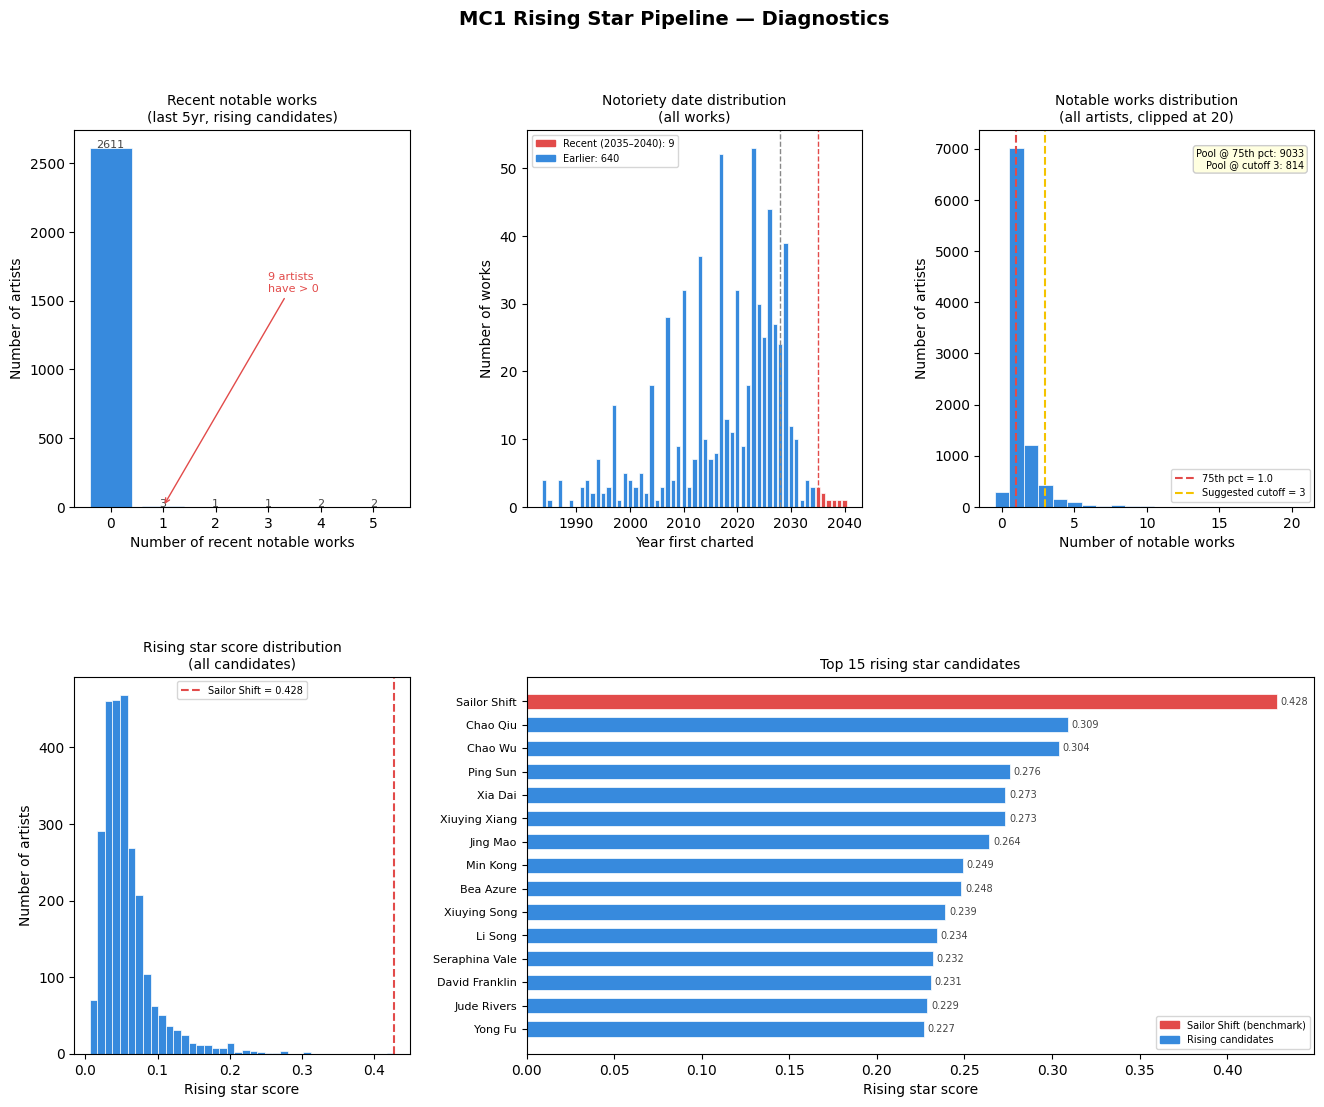

Saved: diagnostics.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(16, 12))
fig.suptitle("MC1 Rising Star Pipeline — Diagnostics", fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── CHART 1: recent_notable_works distribution ────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = rising_candidates["recent_notable_works"].value_counts().sort_index()
ax1.bar(counts.index.astype(int), counts.values, color="#378ADD", edgecolor="white", linewidth=0.5)
ax1.set_title("Recent notable works\n(last 5yr, rising candidates)", fontsize=10)
ax1.set_xlabel("Number of recent notable works")
ax1.set_ylabel("Number of artists")
for i, (x, y) in enumerate(zip(counts.index, counts.values)):
    ax1.text(x, y + 1, str(y), ha="center", fontsize=8, color="#444")
total_nonzero = (rising_candidates["recent_notable_works"] > 0).sum()
ax1.annotate(f"{total_nonzero} artists\nhave > 0",
    xy=(1, counts.get(1, 0)), xytext=(3, counts.values.max() * 0.6),
    arrowprops=dict(arrowstyle="->", color="#E24B4A"), fontsize=8, color="#E24B4A")

# ── CHART 2: notoriety_date distribution (all works) ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
notoriety_years = all_works["notoriety_date"].dropna().astype(int)
year_counts = notoriety_years.value_counts().sort_index()
colors = ["#E24B4A" if y >= 2035 else "#378ADD" for y in year_counts.index]
ax2.bar(year_counts.index, year_counts.values, color=colors, edgecolor="white", linewidth=0.5)
ax2.set_title("Notoriety date distribution\n(all works)", fontsize=10)
ax2.set_xlabel("Year first charted")
ax2.set_ylabel("Number of works")
ax2.axvline(2035, color="#E24B4A", linestyle="--", linewidth=1, label="Recent window start")
ax2.axvline(2028, color="#888", linestyle="--", linewidth=1, label="Sailor's debut")
ax2.legend(fontsize=7)
from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(color="#E24B4A", label=f"Recent (2035–2040): {year_counts[year_counts.index >= 2035].sum()}"),
    Patch(color="#378ADD", label=f"Earlier: {year_counts[year_counts.index < 2035].sum()}")
], fontsize=7)

# ── CHART 3: notable_works distribution (for popular threshold check) ─────────
ax3 = fig.add_subplot(gs[0, 2])
notable_dist = metrics["notable_works"].clip(0, 20)
ax3.hist(notable_dist, bins=21, range=(-0.5, 20.5), color="#378ADD", edgecolor="white", linewidth=0.5)
threshold_75 = metrics["notable_works"].quantile(0.75)
ax3.axvline(threshold_75, color="#E24B4A", linestyle="--", linewidth=1.5,
            label=f"75th pct = {threshold_75:.1f}")
ax3.axvline(3, color="#F4C300", linestyle="--", linewidth=1.5,
            label="Suggested cutoff = 3")
ax3.set_title("Notable works distribution\n(all artists, clipped at 20)", fontsize=10)
ax3.set_xlabel("Number of notable works")
ax3.set_ylabel("Number of artists")
ax3.legend(fontsize=7)
pool_75  = (metrics["notable_works"] >= threshold_75).sum()
pool_3   = (metrics["notable_works"] >= 3).sum()
ax3.text(0.97, 0.95, f"Pool @ 75th pct: {pool_75}\nPool @ cutoff 3: {pool_3}",
    transform=ax3.transAxes, fontsize=7, va="top", ha="right",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="#ccc"))

# ── CHART 4: Rising star score distribution ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(rising_candidates["rising_star_score"], bins=40, color="#378ADD",
         edgecolor="white", linewidth=0.5)
sailor_score = rising_candidates[rising_candidates["name"] == "Sailor Shift"]["rising_star_score"].values
if len(sailor_score):
    ax4.axvline(sailor_score[0], color="#E24B4A", linestyle="--", linewidth=1.5,
                label=f"Sailor Shift = {sailor_score[0]:.3f}")
ax4.set_title("Rising star score distribution\n(all candidates)", fontsize=10)
ax4.set_xlabel("Rising star score")
ax4.set_ylabel("Number of artists")
ax4.legend(fontsize=7)

# ── CHART 5: Top 15 rising candidates — horizontal bar ───────────────────────
ax5 = fig.add_subplot(gs[1, 1:])
top15 = rising_candidates.sort_values("rising_star_score", ascending=False).head(15)
names  = top15["display_name"].fillna("Unknown").tolist()[::-1]
scores = top15["rising_star_score"].tolist()[::-1]
bar_colors = ["#E24B4A" if n == "Sailor Shift" else "#378ADD" for n in names]
bars = ax5.barh(range(len(names)), scores, color=bar_colors, edgecolor="white", linewidth=0.5, height=0.65)
ax5.set_yticks(range(len(names)))
ax5.set_yticklabels(names, fontsize=8)
ax5.set_xlabel("Rising star score")
ax5.set_title("Top 15 rising star candidates", fontsize=10)
for i, (bar, score) in enumerate(zip(bars, scores)):
    ax5.text(score + 0.002, bar.get_y() + bar.get_height() / 2,
             f"{score:.3f}", va="center", fontsize=7, color="#444")
from matplotlib.patches import Patch
ax5.legend(handles=[
    Patch(color="#E24B4A", label="Sailor Shift (benchmark)"),
    Patch(color="#378ADD", label="Rising candidates")
], fontsize=7, loc="lower right")

plt.savefig("diagnostics.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: diagnostics.png")

## Revised: Increase Popular Threshold and Wident RECENT_WINDOW

In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import linregress

# ── LOAD ──────────────────────────────────────────────────────────────────────
nodes = pd.read_csv("../mc1_csv/mc1_nodes.csv")
edges = pd.read_csv("../mc1_csv/mc1_edges.csv")

persons   = nodes[nodes["Node Type"] == "Person"].copy()
songs     = nodes[nodes["Node Type"] == "Song"].copy()
albums    = nodes[nodes["Node Type"] == "Album"].copy()
groups    = nodes[nodes["Node Type"] == "MusicalGroup"].copy()
labels    = nodes[nodes["Node Type"] == "RecordLabel"].copy()
all_works = pd.concat([songs, albums])

all_works["release_date"]   = pd.to_numeric(all_works["release_date"],   errors="coerce")
all_works["notoriety_date"] = pd.to_numeric(all_works["notoriety_date"], errors="coerce")

performer_of = edges[edges["Edge Type"] == "PerformerOf"]
composer_of  = edges[edges["Edge Type"] == "ComposerOf"]
lyricist_of  = edges[edges["Edge Type"] == "LyricistOf"]
in_style_of  = edges[edges["Edge Type"] == "InStyleOf"]
member_of    = edges[edges["Edge Type"] == "MemberOf"]
producer_of  = edges[edges["Edge Type"] == "ProducerOf"]
recorded_by  = edges[edges["Edge Type"] == "RecordedBy"]
distributed  = edges[edges["Edge Type"] == "DistributedBy"]
interpolates = edges[edges["Edge Type"] == "InterpolatesFrom"]
cover_of     = edges[edges["Edge Type"] == "CoverOf"]
lyrical_ref  = edges[edges["Edge Type"] == "LyricalReferenceTo"]
samples      = edges[edges["Edge Type"] == "DirectlySamples"]

all_influence = pd.concat([in_style_of, interpolates, cover_of, lyrical_ref, samples])

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
CURRENT_YEAR  = 2040
SAILOR_ID     = 17255
RECENT_WINDOW = 10    # widened from 3 — covers 2035–2040 for recent notable works
RECENT_COLLAB = 5    # last 5 years for collab activity = 2035–2040
GENRE_WINDOW  = 10   # separate wider window for hot genre detection = 2030–2040
MAX_DEBUT_AGE = 15   # hard filter: debuted 2025 or later

print("=" * 60)
print("VAST MC1 — Rising Star Pipeline")
print("=" * 60)
print(f"Current year : {CURRENT_YEAR}")
print(f"Recent window: last {RECENT_WINDOW} years ({CURRENT_YEAR - RECENT_WINDOW}–{CURRENT_YEAR})")
print(f"Genre window : last {GENRE_WINDOW} years ({CURRENT_YEAR - GENRE_WINDOW}–{CURRENT_YEAR})")
print(f"Debut filter : debuted {CURRENT_YEAR - MAX_DEBUT_AGE} or later")
print()

# ── BASE: artist → works lookup ───────────────────────────────────────────────
artist_works_df = performer_of.merge(
    all_works[["id", "genre", "release_date", "notable", "notoriety_date"]],
    left_on="target", right_on="id", how="left"
).rename(columns={"source": "artist_id"})

artist_works_df["release_date"]   = pd.to_numeric(artist_works_df["release_date"],   errors="coerce")
artist_works_df["notoriety_date"] = pd.to_numeric(artist_works_df["notoriety_date"], errors="coerce")

# Dictionary: artist_id → set of their work IDs (used for influence lookups)
work_ids_by_artist = performer_of.groupby("source")["target"].apply(set).to_dict()

# ── BASE CAREER METRICS ───────────────────────────────────────────────────────
metrics = artist_works_df.groupby("artist_id").agg(
    debut_year      = ("release_date",    "min"),
    latest_year     = ("release_date",    "max"),
    total_works     = ("id",              "count"),
    notable_works   = ("notable",         "sum"),
    first_notoriety = ("notoriety_date",  "min"),
    last_notoriety  = ("notoriety_date",  "max"),
    genre_diversity = ("genre",           "nunique"),
).reset_index()

metrics["notoriety_lag"] = metrics["first_notoriety"] - metrics["debut_year"]
metrics["career_span"]   = metrics["latest_year"] - metrics["debut_year"]

# ── HARD FILTER FLAGS ─────────────────────────────────────────────────────────
# Flag 1: must have at least one PerformerOf edge
performers_set        = set(performer_of["source"].unique())
metrics["is_performer"]     = metrics["artist_id"].isin(performers_set)

# Flag 2: debuted within the last MAX_DEBUT_AGE years
metrics["is_recent_debut"]  = metrics["debut_year"] >= (CURRENT_YEAR - MAX_DEBUT_AGE)

# ── SCORE PARAM 1: RECENT NOTABLE WORKS (last RECENT_WINDOW years) ────────────
# Stronger rising signal than total notable works — recency confirms current momentum
recent_notable = (
    artist_works_df[
        (artist_works_df["release_date"] >= (CURRENT_YEAR - RECENT_WINDOW)) &
        (artist_works_df["notable"] == True)
    ]
    .groupby("artist_id").size()
    .reset_index(name="recent_notable_works")
)
metrics = metrics.merge(recent_notable, on="artist_id", how="left")
metrics["recent_notable_works"] = metrics["recent_notable_works"].fillna(0)

print(f"Artists with recent notable works (last {RECENT_WINDOW}yr): "
      f"{(metrics['recent_notable_works'] > 0).sum()}")

# ── SCORE PARAM 2: OUTBOUND INFLUENCE ────────────────────────────────────────
# How many influence-type edges go FROM this artist's songs TO other songs
# Signals musical engagement and deliberate style-building
metrics["outbound_influence"] = metrics["artist_id"].map(
    lambda aid: all_influence[
        all_influence["source"].isin(work_ids_by_artist.get(aid, set()))
    ].shape[0]
)

# ── SCORE PARAM 3: NOTORIETY RECENCY ──────────────────────────────────────────
# Decays from 1.0 (charted this year) → 0.0 (charted 10+ years ago or never)
# Penalises one-hit wonders whose only chart hit was years ago
metrics["years_since_notoriety"]  = CURRENT_YEAR - metrics["last_notoriety"]
metrics["notoriety_recency_score"] = (
    1 - (metrics["years_since_notoriety"].clip(0, 10) / 10)
).fillna(0)

# ── SCORE PARAM 4: COLLABORATED WITH POPULAR ARTISTS ─────────────────────────
# Popular = top quartile by notable_works + Sailor Shift explicitly included
# Captures the "association effect" — appearing on a track with a star
# exposes you to their audience

popular_ids       = set(metrics[metrics["notable_works"] >= 3]["artist_id"])
popular_ids.add(SAILOR_ID)
print(f"Popular artist pool size: {len(popular_ids)}")

# Build (artist_a, artist_b, song_id, release_date) collab pair table
song_performers = performer_of.groupby("target")["source"].apply(list).reset_index()
shared_songs    = song_performers[song_performers["source"].apply(len) > 1]

collab_pairs = []
for _, row in shared_songs.iterrows():
    perfs   = row["source"]
    song_id = row["target"]
    for i in range(len(perfs)):
        for j in range(i + 1, len(perfs)):
            collab_pairs.append({
                "artist_a": perfs[i],
                "artist_b": perfs[j],
                "song_id":  song_id
            })

collab_df = pd.DataFrame(collab_pairs)
collab_df = collab_df.merge(
    all_works[["id", "release_date"]].rename(columns={"id": "song_id"}),
    on="song_id", how="left"
)
collab_df["release_date"] = pd.to_numeric(collab_df["release_date"], errors="coerce")

# Long format: each artist appears once per row as "artist_id"
collab_long = pd.concat([
    collab_df.rename(columns={"artist_a": "artist_id", "artist_b": "collaborator"}),
    collab_df.rename(columns={"artist_b": "artist_id", "artist_a": "collaborator"})
])[["artist_id", "collaborator", "song_id", "release_date"]]

collab_with_popular = (
    collab_long[collab_long["collaborator"].isin(popular_ids)]
    .groupby("artist_id")["collaborator"].nunique()
    .reset_index(name="collab_with_popular_count")
)
metrics = metrics.merge(collab_with_popular, on="artist_id", how="left")
metrics["collab_with_popular_count"] = metrics["collab_with_popular_count"].fillna(0)

# ── SCORE PARAM 5A: RECENT COLLAB COUNT ──────────────────────────────────────
# Unique collaborators in last RECENT_COLLAB years — are they actively networking?
recent_collab_counts = (
    collab_long[collab_long["release_date"] >= (CURRENT_YEAR - RECENT_COLLAB)]
    .groupby("artist_id")["collaborator"].nunique()
    .reset_index(name="recent_collab_count")
)
metrics = metrics.merge(recent_collab_counts, on="artist_id", how="left")
metrics["recent_collab_count"] = metrics["recent_collab_count"].fillna(0)

# ── SCORE PARAM 5B: COLLAB GROWTH RATE ───────────────────────────────────────
# Slope of cumulative unique collaborators over career
# Captures momentum trend — is the network expanding or flat?
yearly_collabs = (
    collab_long
    .groupby(["artist_id", "release_date"])["collaborator"]
    .nunique()
    .reset_index(name="new_collabs")
    .sort_values(["artist_id", "release_date"])
)
yearly_collabs["cumulative_collabs"] = (
    yearly_collabs.groupby("artist_id")["new_collabs"].cumsum()
)

def calc_slope(group):
    if len(group) < 2:
        return 0.0
    slope, *_ = linregress(group["release_date"], group["cumulative_collabs"])
    return slope

collab_growth = (
    yearly_collabs
    .groupby("artist_id")
    .apply(calc_slope)
    .reset_index(name="collab_growth_rate")
)
metrics = metrics.merge(collab_growth, on="artist_id", how="left")
metrics["collab_growth_rate"] = metrics["collab_growth_rate"].fillna(0)

# ── SCORE PARAM 6: RECENT INBOUND INFLUENCE (recency-adjusted) ────────────────
# Only count inbound influence edges where the CITING song is recent
# Corrects for the crowdsourced data lag (Sailor has inbound=0 without this fix)
recent_citing_ids = set(
    all_works[all_works["release_date"] >= (CURRENT_YEAR - RECENT_COLLAB)]["id"]
)
metrics["recent_inbound_influence"] = metrics["artist_id"].map(
    lambda aid: all_influence[
        (all_influence["target"].isin(work_ids_by_artist.get(aid, set()))) &
        (all_influence["source"].isin(recent_citing_ids))
    ].shape[0]
)

# ── SCORE PARAM 7: GENRE ALIGNMENT ───────────────────────────────────────────
# Uses GENRE_WINDOW (10yr) to identify hot genres — wider than RECENT_WINDOW
# so we get a meaningful top-5 set rather than just Oceanus Folk

recent_works_for_genres = all_works[
    all_works["release_date"] >= (CURRENT_YEAR - GENRE_WINDOW)
]
top_genres = set(
    recent_works_for_genres[recent_works_for_genres["notoriety_date"].notna()]
    .groupby("genre").size()
    .nlargest(5).index
)
print(f"\nTop 5 hot genres ({GENRE_WINDOW}yr window): {top_genres}")

genre_aligned = (
    artist_works_df[
        (artist_works_df["release_date"] >= (CURRENT_YEAR - RECENT_COLLAB)) &
        (artist_works_df["genre"].isin(top_genres))
    ]
    .groupby("artist_id").size()
    .reset_index(name="genre_alignment_score")
)
metrics = metrics.merge(genre_aligned, on="artist_id", how="left")
metrics["genre_alignment_score"] = metrics["genre_alignment_score"].fillna(0)

# ── SCORE PARAM 8: GENRE DIVERSITY ───────────────────────────────────────────
# Already in base metrics — no additional work needed

# ── SCORE PARAM 9: PRESTIGE SCORE ────────────────────────────────────────────
# Label prestige: worked with a label that has produced above-median notable works
label_works_df = pd.concat([
    recorded_by.merge(
        all_works[["id", "notable"]], left_on="source", right_on="id"
    )[["target", "notable"]],
    distributed.merge(
        all_works[["id", "notable"]], left_on="source", right_on="id"
    )[["target", "notable"]]
]).rename(columns={"target": "label_id"})

label_scores = (
    label_works_df[label_works_df["notable"] == True]
    .groupby("label_id").size()
    .reset_index(name="label_notable_count")
)
prestige_labels = set(
    label_scores[
        label_scores["label_notable_count"] >= label_scores["label_notable_count"].median()
    ]["label_id"]
)

artist_songs   = performer_of.rename(columns={"source": "artist_id", "target": "song_id"})
song_label_map = pd.concat([
    recorded_by.rename(columns={"source": "song_id", "target": "label_id"})[["song_id", "label_id"]],
    distributed.rename(columns={"source": "song_id", "target": "label_id"})[["song_id", "label_id"]]
])
artist_label_link = artist_songs.merge(song_label_map, on="song_id")

prestige_label_count = (
    artist_label_link[artist_label_link["label_id"].isin(prestige_labels)]
    .groupby("artist_id")["label_id"].nunique()
    .reset_index(name="prestige_label_count")
)
metrics = metrics.merge(prestige_label_count, on="artist_id", how="left")
metrics["prestige_label_count"] = metrics["prestige_label_count"].fillna(0)

# Group prestige: member of a group whose members have above-median notable works
group_member_scores = (
    member_of
    .merge(metrics[["artist_id", "notable_works"]], left_on="source", right_on="artist_id")
    .groupby("target")["notable_works"].sum()
    .reset_index(name="group_prestige")
)
prestige_groups = set(
    group_member_scores[
        group_member_scores["group_prestige"] >= group_member_scores["group_prestige"].median()
    ]["target"]
)
prestige_group_count = (
    member_of[member_of["target"].isin(prestige_groups)]
    .groupby("source")["target"].nunique()
    .reset_index(name="prestige_group_count")
    .rename(columns={"source": "artist_id"})
)
metrics = metrics.merge(prestige_group_count, on="artist_id", how="left")
metrics["prestige_group_count"] = metrics["prestige_group_count"].fillna(0)

metrics["prestige_score"] = metrics["prestige_label_count"] + metrics["prestige_group_count"]

# ── SCORE PARAM 10: INFLUENCED BY POPULAR ARTISTS ────────────────────────────
# Influence edges from this artist's songs toward charted (notable) songs
# Signals commercial awareness — they know what works in the market
charted_ids = set(all_works[all_works["notoriety_date"].notna()]["id"])

metrics["influenced_by_popular_score"] = metrics["artist_id"].map(
    lambda aid: all_influence[
        (all_influence["source"].isin(work_ids_by_artist.get(aid, set()))) &
        (all_influence["target"].isin(charted_ids))
    ].shape[0]
)

# ── SCORE PARAM 11: ROLE DIVERSITY ───────────────────────────────────────────
# 1 = performer only, 2 = performer + one other role, 3 = all three roles
# Used as colour encoding in Tableau DB5; also a minor score component
role_edges = edges[edges["Edge Type"].isin(["PerformerOf", "ComposerOf", "LyricistOf"])]
role_diversity = (
    role_edges.groupby("source")["Edge Type"].nunique()
    .reset_index(name="role_diversity")
    .rename(columns={"source": "artist_id"})
)
metrics = metrics.merge(role_diversity, on="artist_id", how="left")
metrics["role_diversity"] = metrics["role_diversity"].fillna(0)

# ── OCEANUS FOLK ALIGNMENT (for prediction dashboard) ────────────
# Separate from genre_alignment_score — this specifically measures how much an artist creates and draws from Oceanus Folk, used as the y-axis in the prediction quadrant
# Component 1: count of OF-genre works performed by this artist
of_ids = set(all_works[all_works["genre"] == "Oceanus Folk"]["id"])

of_genre_works = (
    artist_works_df[artist_works_df["genre"] == "Oceanus Folk"]
    .groupby("artist_id")
    .size()
    .reset_index(name="of_genre_works")
)
metrics = metrics.merge(of_genre_works, on="artist_id", how="left")
metrics["of_genre_works"] = metrics["of_genre_works"].fillna(0).astype(int)

# Component 2: influence edges from this artist's songs TO OF works
# (unchanged from before — how much they draw inspiration from OF)
metrics["of_influence_edges"] = metrics["artist_id"].map(
    lambda aid: all_influence[
        (all_influence["source"].isin(work_ids_by_artist.get(aid, set()))) &
        (all_influence["target"].isin(of_ids))
    ].shape[0]
)

# Combined score — simple sum of both components
# You can weight them differently if needed, but equal weight is defensible:
# producing OF music and being inspired by OF music are both valid alignment signals
metrics["of_alignment"] = metrics["of_genre_works"] + metrics["of_influence_edges"]

# Spot-check
print("=== OF ALIGNMENT CHECK ===")
check = metrics[metrics["artist_id"].isin([17255, 1304, 1843])][
    ["artist_id", "of_genre_works", "of_influence_edges", "of_alignment"]
]
print(check.to_string())

# ── ATTACH NAMES ──────────────────────────────────────────────────────────────
metrics = metrics.merge(
    persons[["id", "name", "stage_name"]],
    left_on="artist_id", right_on="id", how="left"
)

# Display name: stage name if available, otherwise real name
metrics["display_name"] = metrics["stage_name"].where(
    metrics["stage_name"].notna(), metrics["name"]
)

# ── APPLY HARD FILTERS ────────────────────────────────────────────────────────
rising_candidates = metrics[
    (metrics["is_performer"]    == True) &
    (metrics["is_recent_debut"] == True) &
    (metrics["name"].notna())             # exclude nameless nodes (data quality gap)
].copy()

print(f"\nCandidates after hard filters: {len(rising_candidates)}")
print(f"  - Excluded non-performers : {(metrics['is_performer'] == False).sum()}")
print(f"  - Excluded old debuts     : {(metrics['is_recent_debut'] == False).sum()}")
print(f"  - Excluded nameless nodes : {metrics['name'].isna().sum()}")

# ── NORMALISE COLLAB COMPONENTS FIRST ────────────────────────────────────────
# Combine recent_collab_count + collab_growth_rate into one collab_score (65/35)
# before the main normalisation pass
scaler_pre = MinMaxScaler()
rising_candidates[["recent_collab_norm_pre", "growth_norm_pre"]] = scaler_pre.fit_transform(
    rising_candidates[["recent_collab_count", "collab_growth_rate"]].fillna(0)
)
rising_candidates["collab_score"] = (
    rising_candidates["recent_collab_norm_pre"] * 0.65 +
    rising_candidates["growth_norm_pre"]         * 0.35
)

# ── SCORE WEIGHTS ─────────────────────────────────────────────────────────────
# Weights sum to 1.00
# notoriety_recency_score and collab_score are already 0–1, skip rescaling
score_components = {
    "recent_notable_works":        0.16,
    "outbound_influence":          0.14,
    "notoriety_recency_score":     0.13,   # already 0–1
    "collab_with_popular_count":   0.12,
    "collab_score":                0.10,   # already 0–1
    "recent_inbound_influence":    0.08,
    "genre_alignment_score":       0.08,
    "genre_diversity":             0.07,
    "prestige_score":              0.05,
    "influenced_by_popular_score": 0.04,
    "role_diversity":              0.03,
}

already_normalised = {"notoriety_recency_score", "collab_score"}
cols_to_scale      = [c for c in score_components if c not in already_normalised]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(rising_candidates[cols_to_scale].fillna(0))
for i, col in enumerate(cols_to_scale):
    rising_candidates[f"{col}_norm"] = scaled[:, i]

for col in already_normalised:
    rising_candidates[f"{col}_norm"] = rising_candidates[col]

# Final score
rising_candidates["rising_star_score"] = sum(
    rising_candidates[f"{col}_norm"] * weight
    for col, weight in score_components.items()
)

# ── RANK ──────────────────────────────────────────────────────────────────────
rising_candidates["rank"] = rising_candidates["rising_star_score"].rank(
    ascending=False, method="min"
)

# ── VALIDATE: SAILOR SHIFT ────────────────────────────────────────────────────
sailor = rising_candidates[rising_candidates["name"] == "Sailor Shift"]
print("\n" + "=" * 60)
print("VALIDATION — SAILOR SHIFT")
print("=" * 60)
if len(sailor) > 0:
    print(f"Rank  : {int(sailor['rank'].values[0])} / {len(rising_candidates)}")
    print(f"Score : {sailor['rising_star_score'].values[0]:.4f}")
    print("\nComponent breakdown:")
    for col in score_components:
        norm_val = sailor[f"{col}_norm"].values[0]
        raw_val  = sailor[col].values[0]
        print(f"  {col:<35} raw={raw_val:>7.2f}  norm={norm_val:.3f}  contrib={norm_val * score_components[col]:.4f}")
else:
    print("Sailor Shift not found — check is_performer and is_recent_debut flags")
    print(metrics[metrics["name"] == "Sailor Shift"][
        ["name","is_performer","is_recent_debut","debut_year"]
    ].to_string())

# ── DEBUG: COMPONENT BREAKDOWN FOR TOP 10 ────────────────────────────────────
print("\n" + "=" * 60)
print("TOP 10 — COMPONENT SCORES")
print("=" * 60)
norm_cols = [f"{c}_norm" for c in score_components]
top10 = rising_candidates.sort_values("rising_star_score", ascending=False).head(10)
print(top10[["rank", "display_name", "debut_year", "rising_star_score"] + norm_cols].to_string())

# ── TOP 10 SUMMARY ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TOP 10 RISING STARS — SUMMARY")
print("=" * 60)
summary_cols = [
    "rank", "display_name", "debut_year", "rising_star_score",
    "recent_notable_works", "outbound_influence", "collab_with_popular_count",
    "recent_collab_count", "of_alignment", "role_diversity", "genre_diversity"
]
print(top10[summary_cols].to_string())

# ── CLEAN DATATYPES BEFORE EXPORT ────────────────────────────────────────────

# Columns that should be whole-number years — convert float to nullable integer
year_cols = [
    "debut_year", "latest_year", "first_notoriety", "last_notoriety",
    "career_span", "notoriety_lag", "years_since_notoriety"
]
for col in year_cols:
    if col in metrics.columns:
        metrics[col] = pd.to_numeric(metrics[col], errors="coerce").astype("Int64")
    if col in rising_candidates.columns:
        rising_candidates[col] = pd.to_numeric(rising_candidates[col], errors="coerce").astype("Int64")

# Columns that should be whole-number counts
count_cols = [
    "total_works", "notable_works", "recent_notable_works",
    "outbound_influence", "inbound_influence", "recent_inbound_influence",
    "collab_with_popular_count", "recent_collab_count",
    "genre_diversity", "role_diversity", "of_alignment",
    "prestige_score", "prestige_label_count", "prestige_group_count",
    "influenced_by_popular_score", "genre_alignment_score"
]
for col in count_cols:
    if col in metrics.columns:
        metrics[col] = pd.to_numeric(metrics[col], errors="coerce").astype("Int64")
    if col in rising_candidates.columns:
        rising_candidates[col] = pd.to_numeric(rising_candidates[col], errors="coerce").astype("Int64")

# Score columns stay as float — round to 4 decimal places for clean display
score_cols = [
    "rising_star_score", "notoriety_recency_score", "collab_score",
    "collab_growth_rate"
]
for col in score_cols:
    if col in rising_candidates.columns:
        rising_candidates[col] = rising_candidates[col].round(4)

print("Datatypes cleaned.")
print(metrics[["debut_year", "notable_works", "genre_diversity"]].dtypes)

# ── EXPORT ALL CSVS ───────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("EXPORTING CSVs")
print("=" * 60)

# 1. Full metrics — all artists, all fields (for Tableau data model)
metrics.to_csv("artist_metrics_full.csv", index=False)
print("  artist_metrics_full.csv")

# 2. Scored rising candidates — filtered, scored, ranked (for DB5)
rising_candidates.to_csv("rising_stars_scored.csv", index=False)
print("  rising_stars_scored.csv")

# 3. Yearly collab trajectory — one row per artist per year (for DB4 lines)
yearly_collabs_export = yearly_collabs.merge(
    persons[["id", "name", "stage_name"]], left_on="artist_id", right_on="id", how="left"
)
yearly_collabs_export["display_name"] = yearly_collabs_export["stage_name"].where(
    yearly_collabs_export["stage_name"].notna(), yearly_collabs_export["name"]
)
yearly_collabs_export.to_csv("yearly_collabs.csv", index=False)
print("  yearly_collabs.csv")

# 4. Influence edges enriched with source/target genre + year (for DB3)
influence_edges_export = all_influence.copy()
work_attrs = all_works[["id", "genre", "release_date"]].set_index("id")
influence_edges_export["source_genre"] = influence_edges_export["source"].map(
    lambda x: work_attrs["genre"].get(x)
)
influence_edges_export["source_year"]  = influence_edges_export["source"].map(
    lambda x: work_attrs["release_date"].get(x)
)
influence_edges_export["target_genre"] = influence_edges_export["target"].map(
    lambda x: work_attrs["genre"].get(x)
)
influence_edges_export.to_csv("influence_edges.csv", index=False)
print("  influence_edges.csv")

# 5. Sailor ego network nodes — artist IDs within 2 hops (for DB2)
import networkx as nx
G_collab = nx.from_pandas_edgelist(
    performer_of, source="source", target="target", create_using=nx.Graph()
)
if SAILOR_ID in G_collab:
    ego_1 = set(nx.ego_graph(G_collab, SAILOR_ID, radius=1).nodes())
    ego_2 = set(nx.ego_graph(G_collab, SAILOR_ID, radius=2).nodes())
    sailor_ego = metrics[metrics["artist_id"].isin(ego_2)].copy()
    sailor_ego["hop"] = sailor_ego["artist_id"].map(
        lambda x: 0 if x == SAILOR_ID else (1 if x in ego_1 else 2)
    )
    sailor_ego.to_csv("sailor_ego_nodes.csv", index=False)
    print(f"  sailor_ego_nodes.csv  ({len(sailor_ego)} nodes, depth=2)")

print("\nDone.")

VAST MC1 — Rising Star Pipeline
Current year : 2040
Recent window: last 10 years (2030–2040)
Genre window : last 10 years (2030–2040)
Debut filter : debuted 2025 or later

Artists with recent notable works (last 10yr): 258
Popular artist pool size: 814

Top 5 hot genres (10yr window): {'Americana', 'Dream Pop', 'Desert Rock', 'Oceanus Folk', 'Alternative Rock'}
=== OF ALIGNMENT CHECK ===
      artist_id  of_genre_works  of_influence_edges  of_alignment
684        1304               1                   0             1
987        1843               4                   3             7
9306      17255              26                   0            26

Candidates after hard filters: 2620
  - Excluded non-performers : 0
  - Excluded old debuts     : 6660
  - Excluded nameless nodes : 218

VALIDATION — SAILOR SHIFT
Rank  : 1 / 2620
Score : 0.4471

Component breakdown:
  recent_notable_works                raw=  12.00  norm=1.000  contrib=0.1600
  outbound_influence                  raw=  19.0

In [10]:
top15 = rising_candidates.sort_values("rising_star_score", ascending=False).head(15)
print(top15[["rank","name","debut_year","rising_star_score",
             "recent_notable_works","of_alignment","role_diversity", "collab_score"]].to_string())

      rank               name  debut_year  rising_star_score  recent_notable_works  of_alignment  role_diversity  collab_score
9306   1.0       Sailor Shift        2028             0.4471                    12             0               2        0.0700
9313   2.0  Beatrice Albright        2031             0.3706                     8             2               2        0.6823
755    3.0           Ping Sun        2026             0.3321                     0             3               2        0.0925
9314   4.0   Daniel O'Connell        2031             0.3248                     8             0               2        0.6823
567    5.0           Chao Qiu        2026             0.3097                     0             0               2        0.1700
2982   6.0      Xiuying Xiang        2025             0.2876                     0             0               1        0.3220
2980   6.0            Xia Dai        2025             0.2876                     0             0               

In [11]:
tied = rising_candidates[
    rising_candidates["name"].isin(["Xiuying Xiang", "Xia Dai"])
]
component_cols = [f"{c}_norm" for c in score_components]
print(tied[["name"] + component_cols].to_string())

               name  recent_notable_works_norm  outbound_influence_norm  notoriety_recency_score_norm  collab_with_popular_count_norm  collab_score_norm  recent_inbound_influence_norm  genre_alignment_score_norm  genre_diversity_norm  prestige_score_norm  influenced_by_popular_score_norm  role_diversity_norm
1082  Xiuying Xiang                        0.0                 0.041667                           0.0                        0.142857              0.000                            0.0                         0.0                   0.0                  0.0                             0.000                  0.0
2980        Xia Dai                        0.0                 0.375000                           0.0                        0.857143              0.322                            0.0                         0.0                   1.0                  0.6                             0.000                  0.0
2982  Xiuying Xiang                        0.0                 0.37500

In [12]:
num_candidates = rising_candidates["artist_id"].nunique()
print("Number of rising candidates:", num_candidates)

Number of rising candidates: 2620


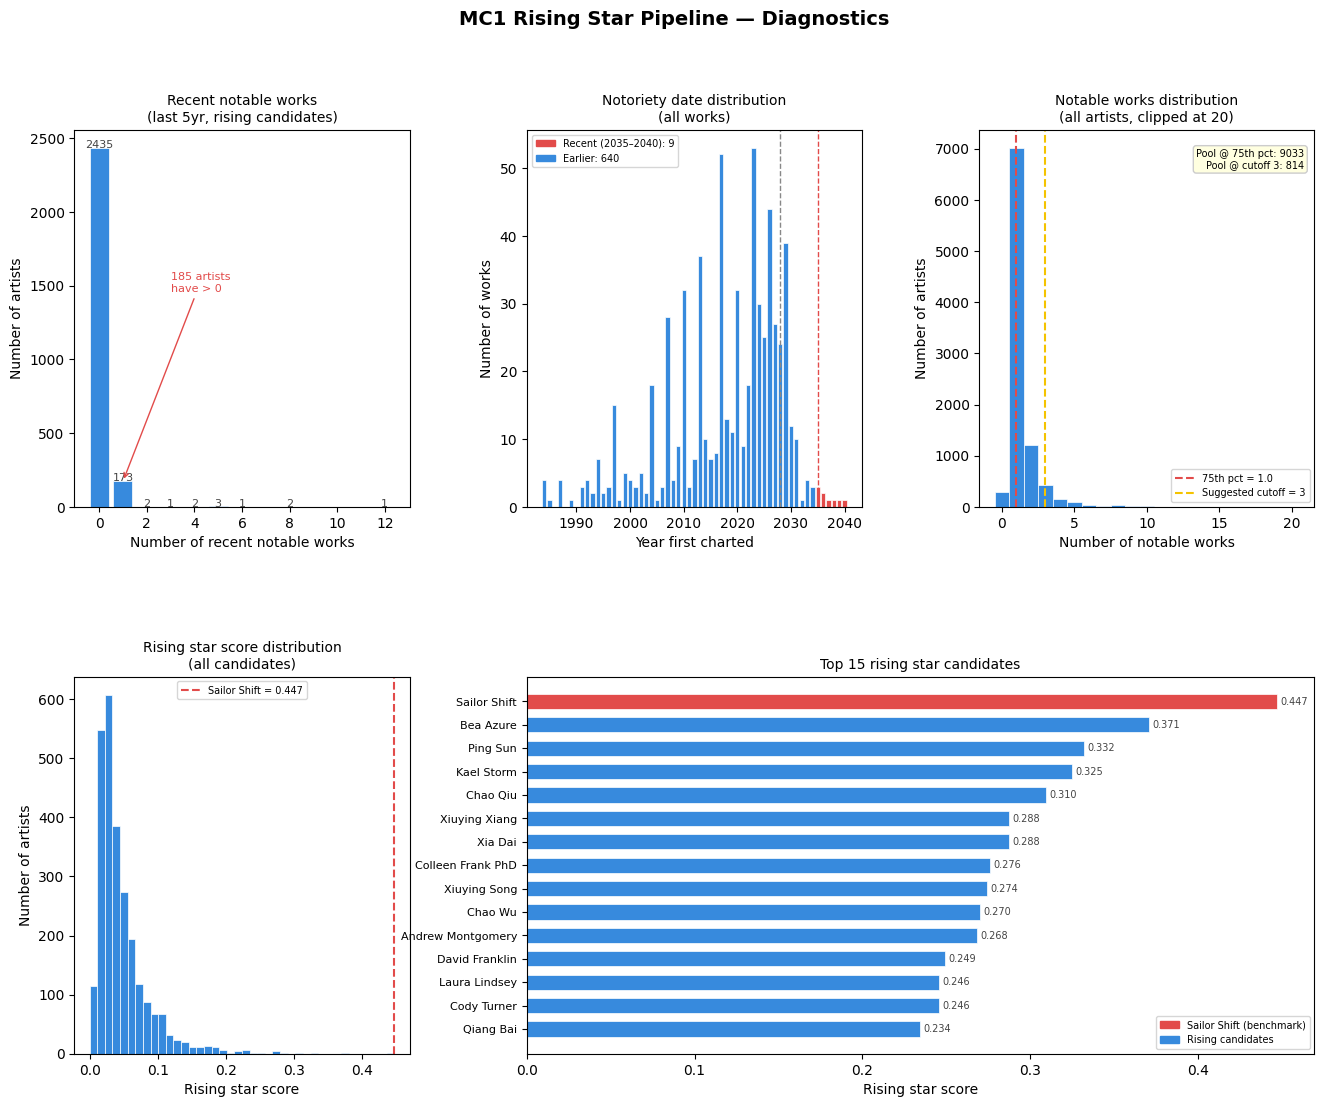

Saved: diagnostics.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(16, 12))
fig.suptitle("MC1 Rising Star Pipeline — Diagnostics", fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── CHART 1: recent_notable_works distribution ────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = rising_candidates["recent_notable_works"].value_counts().sort_index()
ax1.bar(counts.index.astype(int), counts.values, color="#378ADD", edgecolor="white", linewidth=0.5)
ax1.set_title("Recent notable works\n(last 5yr, rising candidates)", fontsize=10)
ax1.set_xlabel("Number of recent notable works")
ax1.set_ylabel("Number of artists")
for i, (x, y) in enumerate(zip(counts.index, counts.values)):
    ax1.text(x, y + 1, str(y), ha="center", fontsize=8, color="#444")
total_nonzero = (rising_candidates["recent_notable_works"] > 0).sum()
ax1.annotate(f"{total_nonzero} artists\nhave > 0",
    xy=(1, counts.get(1, 0)), xytext=(3, counts.values.max() * 0.6),
    arrowprops=dict(arrowstyle="->", color="#E24B4A"), fontsize=8, color="#E24B4A")

# ── CHART 2: notoriety_date distribution (all works) ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
notoriety_years = all_works["notoriety_date"].dropna().astype(int)
year_counts = notoriety_years.value_counts().sort_index()
colors = ["#E24B4A" if y >= 2035 else "#378ADD" for y in year_counts.index]
ax2.bar(year_counts.index, year_counts.values, color=colors, edgecolor="white", linewidth=0.5)
ax2.set_title("Notoriety date distribution\n(all works)", fontsize=10)
ax2.set_xlabel("Year first charted")
ax2.set_ylabel("Number of works")
ax2.axvline(2035, color="#E24B4A", linestyle="--", linewidth=1, label="Recent window start")
ax2.axvline(2028, color="#888", linestyle="--", linewidth=1, label="Sailor's debut")
ax2.legend(fontsize=7)
from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(color="#E24B4A", label=f"Recent (2035–2040): {year_counts[year_counts.index >= 2035].sum()}"),
    Patch(color="#378ADD", label=f"Earlier: {year_counts[year_counts.index < 2035].sum()}")
], fontsize=7)

# ── CHART 3: notable_works distribution (for popular threshold check) ─────────
ax3 = fig.add_subplot(gs[0, 2])
notable_dist = metrics["notable_works"].clip(0, 20)
ax3.hist(notable_dist, bins=21, range=(-0.5, 20.5), color="#378ADD", edgecolor="white", linewidth=0.5)
threshold_75 = metrics["notable_works"].quantile(0.75)
ax3.axvline(threshold_75, color="#E24B4A", linestyle="--", linewidth=1.5,
            label=f"75th pct = {threshold_75:.1f}")
ax3.axvline(3, color="#F4C300", linestyle="--", linewidth=1.5,
            label="Suggested cutoff = 3")
ax3.set_title("Notable works distribution\n(all artists, clipped at 20)", fontsize=10)
ax3.set_xlabel("Number of notable works")
ax3.set_ylabel("Number of artists")
ax3.legend(fontsize=7)
pool_75  = (metrics["notable_works"] >= threshold_75).sum()
pool_3   = (metrics["notable_works"] >= 3).sum()
ax3.text(0.97, 0.95, f"Pool @ 75th pct: {pool_75}\nPool @ cutoff 3: {pool_3}",
    transform=ax3.transAxes, fontsize=7, va="top", ha="right",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="#ccc"))

# ── CHART 4: Rising star score distribution ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(rising_candidates["rising_star_score"], bins=40, color="#378ADD",
         edgecolor="white", linewidth=0.5)
sailor_score = rising_candidates[rising_candidates["name"] == "Sailor Shift"]["rising_star_score"].values
if len(sailor_score):
    ax4.axvline(sailor_score[0], color="#E24B4A", linestyle="--", linewidth=1.5,
                label=f"Sailor Shift = {sailor_score[0]:.3f}")
ax4.set_title("Rising star score distribution\n(all candidates)", fontsize=10)
ax4.set_xlabel("Rising star score")
ax4.set_ylabel("Number of artists")
ax4.legend(fontsize=7)

# ── CHART 5: Top 15 rising candidates — horizontal bar ───────────────────────
ax5 = fig.add_subplot(gs[1, 1:])
top15 = rising_candidates.sort_values("rising_star_score", ascending=False).head(15)
names  = top15["display_name"].fillna("Unknown").tolist()[::-1]
scores = top15["rising_star_score"].tolist()[::-1]
bar_colors = ["#E24B4A" if n == "Sailor Shift" else "#378ADD" for n in names]
bars = ax5.barh(range(len(names)), scores, color=bar_colors, edgecolor="white", linewidth=0.5, height=0.65)
ax5.set_yticks(range(len(names)))
ax5.set_yticklabels(names, fontsize=8)
ax5.set_xlabel("Rising star score")
ax5.set_title("Top 15 rising star candidates", fontsize=10)
for i, (bar, score) in enumerate(zip(bars, scores)):
    ax5.text(score + 0.002, bar.get_y() + bar.get_height() / 2,
             f"{score:.3f}", va="center", fontsize=7, color="#444")
from matplotlib.patches import Patch
ax5.legend(handles=[
    Patch(color="#E24B4A", label="Sailor Shift (benchmark)"),
    Patch(color="#378ADD", label="Rising candidates")
], fontsize=7, loc="lower right")

plt.savefig("diagnostics.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: diagnostics.png")

In [14]:
num_candidates = rising_candidates["artist_id"].duplicated()
print("Number of rising candidates:", num_candidates)

Number of rising candidates: 4       False
6       False
7       False
8       False
17      False
        ...  
9307    False
9312    False
9313    False
9314    False
9316    False
Name: artist_id, Length: 2620, dtype: bool


## Selecting candidate to visualise

In [16]:
import pandas as pd

# Load base graph tables
nodes = pd.read_csv("../mc1_csv/mc1_nodes.csv")
edges = pd.read_csv("../mc1_csv/mc1_edges.csv")

# Split nodes and keep musical works (songs + albums)
songs = nodes[nodes["Node Type"] == "Song"].copy()
albums = nodes[nodes["Node Type"] == "Album"].copy()
all_works = pd.concat([songs, albums], ignore_index=True)

# Core relationships
performer_of = edges[edges["Edge Type"] == "PerformerOf"][["source", "target"]].rename(
    columns={"source": "artist_id", "target": "work_id"}
)

influence_edge_types = [
    "InStyleOf",
    "InterpolatesFrom",
    "CoverOf",
    "LyricalReferenceTo",
    "DirectlySamples",
]
all_influence = edges[edges["Edge Type"].isin(influence_edge_types)][["source", "target", "Edge Type"]].rename(
    columns={"source": "source_work_id", "target": "target_work_id"}
)

# 1) Identify Oceanus Folk artists: artists who performed at least one Oceanus Folk work
of_work_ids = set(all_works[all_works["genre"] == "Oceanus Folk"]["id"].dropna())
of_artists = set(performer_of[performer_of["work_id"].isin(of_work_ids)]["artist_id"].dropna())

# 2) Build work -> set(artists) mapping (to translate work-level influence to artist-level influence)
work_to_artists = performer_of.groupby("work_id")["artist_id"].apply(set).to_dict()

# 3) Outbound influence per artist: artist's performed work appears as source of an influence edge
outbound_rows = all_influence.assign(
    artist_id=all_influence["source_work_id"].map(work_to_artists)
).explode("artist_id").dropna(subset=["artist_id"])
,
outbound_counts = outbound_rows.groupby("artist_id").size().rename("outbound_influence")

# 4) Inbound influence per artist: artist's performed work appears as target of an influence edge
inbound_rows = all_influence.assign(
    artist_id=all_influence["target_work_id"].map(work_to_artists)
).explode("artist_id").dropna(subset=["artist_id"])
,
inbound_counts = inbound_rows.groupby("artist_id").size().rename("inbound_influence")

# 5) Combine, keep only Oceanus Folk artists
artist_influence = pd.concat([outbound_counts, inbound_counts], axis=1).fillna(0)
artist_influence[["outbound_influence", "inbound_influence"]] = artist_influence[[
    "outbound_influence", "inbound_influence"
 ]].astype(int)
artist_influence = artist_influence.loc[artist_influence.index.isin(of_artists)].copy()

# Attach artist names
persons = nodes[nodes["Node Type"] == "Person"][["id", "name", "stage_name"]].copy()
artist_influence = artist_influence.reset_index().rename(columns={"index": "artist_id"})
artist_influence = artist_influence.merge(
    persons, left_on="artist_id", right_on="id", how="left"
)
artist_influence["display_name"] = artist_influence["stage_name"].where(
    artist_influence["stage_name"].notna(), artist_influence["name"]
)

# Top 10 Oceanus Folk artists by outbound and inbound influence
top10_outbound = artist_influence.sort_values(
    ["outbound_influence", "inbound_influence"], ascending=False
).head(10)

top10_inbound = artist_influence.sort_values(
    ["inbound_influence", "outbound_influence"], ascending=False
).head(10)

print("Top 10 Oceanus Folk artists by OUTBOUND influence")
print(top10_outbound[[
    "artist_id", "display_name", "outbound_influence", "inbound_influence"
]].to_string(index=False))

print("\nTop 10 Oceanus Folk artists by INBOUND influence")
print(top10_inbound[[
    "artist_id", "display_name", "inbound_influence", "outbound_influence"
]].to_string(index=False))

Top 10 Oceanus Folk artists by OUTBOUND influence
 artist_id     display_name  outbound_influence  inbound_influence
      1304     Rüdiger Graf                  27                  5
      1952         Yang Wan                  20                 43
      1519          Min Lei                  20                  1
     17255     Sailor Shift                  19                  0
      3504 Zacharie Martins                  13                 32
      7398  Charles Vazquez                  13                  6
      2006    Filippo Pelli                  12                 17
      5382        Yong Wang                  12                 10
      3716        Qiang Xie                  12                  6
      1346    Xiuying Huang                  11                 13

Top 10 Oceanus Folk artists by INBOUND influence
 artist_id     display_name  inbound_influence  outbound_influence
      1843         Chao Tan                157                   6
      1952         Yang Wan  

In [24]:
chao_tan = artist_influence[
    artist_influence['display_name'].str.contains('Chao Tan', na=False)
]
print(chao_tan[['artist_id','display_name','inbound_influence','outbound_influence']].to_string())

# Then pull their full metrics from artist_metrics_full
chao_id = 1843
full = pd.read_csv('artist_metrics_full.csv')
print(full[full['artist_id'] == chao_id][[
    'name','debut_year','latest_year','total_works','notable_works',
    'first_notoriety','notoriety_lag','genre_diversity','role_diversity',
    'collab_growth_rate','outbound_influence'
]].to_string())

     artist_id display_name  inbound_influence  outbound_influence
45        1843     Chao Tan                157                   6
114       3831    Chao Tang                  3                   1
         name  debut_year  latest_year  total_works  notable_works  first_notoriety  notoriety_lag  genre_diversity  role_diversity  collab_growth_rate  outbound_influence
987  Chao Tan        2010         2023            5              5              NaN            NaN                2               1            1.216535                   6


In [30]:
import pandas as pd
df = pd.read_csv("rising_stars_scored.csv")

# Find percentile cutoffs
for p in [50, 60, 70, 75, 80]:
    val = df["rising_star_score"].quantile(p/100)
    n   = (df["rising_star_score"] >= val).sum()
    print(f"Top {100-p}% (score >= {val:.3f}): {n} artists")

Top 50% (score >= 0.037): 1317 artists
Top 40% (score >= 0.043): 1058 artists
Top 30% (score >= 0.051): 792 artists
Top 25% (score >= 0.057): 655 artists
Top 20% (score >= 0.066): 527 artists


In [ ]:
# Sailor Shift summary table
sailor_shift_summary = metrics[metrics["display_name"] == "Sailor Shift"][ [
    "artist_id",
    "display_name",
    "outbound_influence",
    "recent_collab_count",
    "collab_growth_rate",
    "has_musical_group",
    "group_membership_count",
    "has_musical_group",
    "group_membership_count",
    "notable_works",
    "genre_diversity",
    "first_notoriety",
    "last_notoriety",
    "notoriety_lag",
    "career_span",
    "of_alignment",
    "role_diversity",
] ].copy()

# Total collaborations = unique collaborators across all years
total_collabs = (
    collab_long.groupby("artist_id")["collaborator"]
    .nunique()
    .reset_index(name="total_collabs")
)
sailor_shift_summary = sailor_shift_summary.merge(total_collabs, on="artist_id", how="left")

# Merge inbound influence from the legacy metrics CSV
legacy_metrics = pd.read_csv("theme3_ver1/artist_metrics.csv")[["artist_id", "inbound_influence"]]
sailor_shift_summary = sailor_shift_summary.merge(legacy_metrics, on="artist_id", how="left")

# If display_name is missing for some reason, fall back to name
if sailor_shift_summary.empty:
    sailor_shift_summary = metrics[metrics["name"] == "Sailor Shift"][ [
        "artist_id",
        "name",
        "outbound_influence",
        "recent_collab_count",
        "collab_growth_rate",
        "total_collabs",
        "has_musical_group", 
        "group_membership_count",
        "notable_works",
        "genre_diversity",
        "first_notoriety",
        "last_notoriety",
        "notoriety_lag",
        "career_span",
        "of_alignment",
        "role_diversity",
] ].copy()
    sailor_shift_summary = sailor_shift_summary.rename(columns={"name": "display_name"})
    sailor_shift_summary = sailor_shift_summary.merge(total_collabs, on="artist_id", how="left")
    sailor_shift_summary = sailor_shift_summary.merge(legacy_metrics, on="artist_id", how="left")

print(sailor_shift_summary.to_string(index=False))
sailor_shift_summary

 artist_id display_name  outbound_influence  recent_collab_count  collab_growth_rate  has_musical_group  group_membership_count  has_musical_group  group_membership_count  notable_works  genre_diversity  first_notoriety  last_notoriety  notoriety_lag  career_span  of_alignment  role_diversity  total_collabs  inbound_influence
     17255 Sailor Shift                  19                    0                 2.0               True                       1               True                       1             14                1             2030            2030              2           12            26               2              3                  0


,artist_id,display_name,outbound_influence,recent_collab_count,collab_growth_rate,has_musical_group,group_membership_count,has_musical_group,group_membership_count,notable_works,genre_diversity,first_notoriety,last_notoriety,notoriety_lag,career_span,of_alignment,role_diversity,total_collabs,inbound_influence
0,17255,Sailor Shift,19,0,2.0,True,1,True,1,14,1,2030,2030,2,12,26,2,3,0


In [37]:
# Add a musical-group membership field to metrics
group_memberships = (
    member_of.groupby("source")["target"]
    .nunique()
    .reset_index(name="group_membership_count")
)

metrics = metrics.merge(group_memberships, left_on="artist_id", right_on="source", how="left")
metrics["group_membership_count"] = metrics["group_membership_count"].fillna(0).astype(int)
metrics["has_musical_group"] = metrics["group_membership_count"] > 0
metrics = metrics.drop(columns=["source"])

print(metrics[["artist_id", "name", "has_musical_group", "group_membership_count"]].head())

   artist_id            name  has_musical_group  group_membership_count
0          1    Carlos Duffy              False                       0
1          2         Min Qin              False                       0
2          3     Xiuying Xie              False                       0
3          7     Xiulan Zeng               True                       1
4          8  David Franklin               True                       1


## Assessing Musical Group Status and Influence Factor

In [46]:
import pandas as pd

nodes = pd.read_csv("../mc1_csv/mc1_nodes.csv")
edges = pd.read_csv("../mc1_csv/mc1_edges.csv")

persons   = nodes[nodes["Node Type"] == "Person"].copy()
groups    = nodes[nodes["Node Type"] == "MusicalGroup"].copy()
songs     = nodes[nodes["Node Type"] == "Song"].copy()
albums    = nodes[nodes["Node Type"] == "Album"].copy()
all_works = pd.concat([songs, albums])
all_works["release_date"] = pd.to_numeric(all_works["release_date"], errors="coerce")

member_of    = edges[edges["Edge Type"] == "MemberOf"]
performer_of = edges[edges["Edge Type"] == "PerformerOf"]
influence_types = ["InStyleOf","InterpolatesFrom","CoverOf","LyricalReferenceTo","DirectlySamples"]
all_influence = edges[edges["Edge Type"].isin(influence_types)]

SAILOR_ID = 17255

# ── STEP 1: CONFIRM IVY ECHOES AND SAILOR'S MEMBERSHIP ───────────────────────
print("=== IVY ECHOES ===")
ivy = groups[groups["name"].str.contains("Ivy", na=False, case=False)]
print(ivy[["id","name"]].to_string())

ivy_id      = ivy["id"].values[0]
ivy_members = member_of[member_of["target"] == ivy_id]
print(f"\nMembers of Ivy Echoes:")
print(persons[persons["id"].isin(ivy_members["source"])][["id","name","stage_name"]].to_string())

# ── STEP 2: SCORE EVERY MUSICAL GROUP BY INFLUENCE ───────────────────────────
# A group's influence = inbound influence on its performed works
# (how many times other artists have cited the group's songs)

# Works performed by each group
group_works = performer_of[
    performer_of["source"].isin(groups["id"])
].rename(columns={"source":"group_id","target":"work_id"})

# Inbound influence per group
group_inbound = (
    all_influence[all_influence["target"].isin(group_works["work_id"])]
    .merge(group_works, left_on="target", right_on="work_id")
    .groupby("group_id").size()
    .reset_index(name="group_inbound_influence")
)

# Outbound influence per group
group_outbound = (
    all_influence[all_influence["source"].isin(group_works["work_id"])]
    .merge(group_works, left_on="source", right_on="work_id")
    .groupby("group_id").size()
    .reset_index(name="group_outbound_influence")
)

# Notable works per group
group_notable = (
    group_works.merge(
        all_works[["id","notable","genre","release_date"]],
        left_on="work_id", right_on="id", how="left"
    )
    .groupby("group_id").agg(
        group_total_works   = ("work_id","count"),
        group_notable_works = ("notable","sum"),
        group_debut_year    = ("release_date","min"),
        group_latest_year   = ("release_date","max"),
    ).reset_index()
)

# Combine into group scores
group_scores = groups[["id","name"]].rename(columns={"id":"group_id","name":"group_name"})
group_scores = group_scores.merge(group_inbound,  on="group_id", how="left")
group_scores = group_scores.merge(group_outbound, on="group_id", how="left")
group_scores = group_scores.merge(group_notable,  on="group_id", how="left")

# Ensure numeric metrics are numeric before ranking
numeric_cols = [
    "group_inbound_influence",
    "group_outbound_influence",
    "group_total_works",
    "group_notable_works",
    "group_debut_year",
    "group_latest_year",
]
for col in numeric_cols:
    group_scores[col] = pd.to_numeric(group_scores[col], errors="coerce").fillna(0)

# Group prestige score = inbound + notable works (both signal impact)
group_scores["group_prestige"] = (
    group_scores["group_inbound_influence"] +
    group_scores["group_notable_works"]
)
group_scores["group_prestige"] = pd.to_numeric(group_scores["group_prestige"], errors="coerce").fillna(0)

print("\n=== TOP 15 MUSICAL GROUPS BY PRESTIGE ===")
print(group_scores.nlargest(15, "group_prestige")[
    ["group_name","group_prestige","group_inbound_influence",
     "group_notable_works","group_total_works","group_debut_year"]
].to_string())

# ── STEP 3: LINK ARTISTS TO THEIR GROUP METRICS ───────────────────────────────
# One artist can be in multiple groups — take the max prestige group they belonged to
artist_groups = member_of.rename(
    columns={"source":"artist_id","target":"group_id"}
).merge(group_scores, on="group_id", how="left")

# Per artist: which group was their most prestigious?
artist_best_group = (
    artist_groups.sort_values("group_prestige", ascending=False)
    .groupby("artist_id")
    .first()
    .reset_index()
)[["artist_id","group_id","group_name","group_prestige",
   "group_inbound_influence","group_notable_works","group_debut_year"]]

# Was this artist ever in ANY group?
artist_best_group["was_in_group"] = True

# ── STEP 4: DEFINE HIGH-INFLUENCE GROUP THRESHOLD ────────────────────────────
threshold = group_scores["group_prestige"].quantile(0.75)
print(f"\n=== GROUP PRESTIGE THRESHOLD (75th pct) = {threshold:.1f} ===")
artist_best_group["was_in_high_influence_group"] = (
    artist_best_group["group_prestige"] >= threshold
)

# ── STEP 5: CHECK IVY ECHOES SPECIFICALLY ────────────────────────────────────
ivy_score = group_scores[group_scores["group_id"] == ivy_id]
print("\n=== IVY ECHOES SCORE ===")
print(ivy_score[["group_name","group_prestige","group_inbound_influence",
                  "group_notable_works","group_total_works"]].to_string())

ivy_percentile = (group_scores["group_prestige"] < ivy_score["group_prestige"].values[0]).mean() * 100
print(f"Ivy Echoes percentile: {ivy_percentile:.1f}th (of all {len(group_scores)} groups)")

# ── STEP 6: MERGE INTO artist_metrics_full AND rising_stars_scored ────────────
metrics = pd.read_csv("artist_metrics_full.csv")
rising  = pd.read_csv("rising_stars_scored.csv")

enrichment_cols = [
    "was_in_group",
    "was_in_high_influence_group",
    "group_name",
    "group_prestige",
    "group_inbound_influence",
    "group_notable_works",
]

for df, fname in [(metrics, "artist_metrics_full.csv"),
                  (rising,  "rising_stars_scored.csv")]:
    existing = [c for c in enrichment_cols if c in df.columns]
    if existing:
        df = df.drop(columns=existing)

    df = df.merge(
        artist_best_group[[
            "artist_id","was_in_group","was_in_high_influence_group",
            "group_name","group_prestige","group_inbound_influence",
            "group_notable_works"
        ]],
        on="artist_id", how="left"
    )
    df["was_in_group"]                = df["was_in_group"].fillna(False)
    df["was_in_high_influence_group"] = df["was_in_high_influence_group"].fillna(False)
    df["group_name"]                  = df["group_name"].fillna("None")
    df["group_prestige"]              = df["group_prestige"].fillna(0).astype(int)
    df["group_inbound_influence"]     = df["group_inbound_influence"].fillna(0).astype(int)
    df["group_notable_works"]         = df["group_notable_works"].fillna(0).astype(int)
    df.to_csv(fname, index=False)
    print(f"\nUpdated: {fname}")
    print(f"  was_in_group = True:                {df['was_in_group'].sum()}")
    print(f"  was_in_high_influence_group = True:  {df['was_in_high_influence_group'].sum()}")

# ── STEP 7: ALSO ADD TO three_artists_db4.csv IF IT EXISTS ───────────────────
try:
    three = pd.read_csv("three_artists_db4.csv")
    existing_three = [c for c in ["was_in_group","was_in_high_influence_group","group_name","group_prestige"] if c in three.columns]
    if existing_three:
        three = three.drop(columns=existing_three)

    three = three.merge(
        artist_best_group[[
            "artist_id","was_in_group","was_in_high_influence_group",
            "group_name","group_prestige"
        ]],
        on="artist_id", how="left"
    )
    three["was_in_group"]                = three["was_in_group"].fillna(False)
    three["was_in_high_influence_group"] = three["was_in_high_influence_group"].fillna(False)
    three["group_name"]                  = three["group_name"].fillna("None")
    three["group_prestige"]              = three["group_prestige"].fillna(0)
    three.to_csv("three_artists_db4.csv", index=False)
    print("\nUpdated: three_artists_db4.csv")
except FileNotFoundError:
    print("\nthree_artists_db4.csv not found — skipping")

# ── STEP 8: SPOT CHECK THE THREE DB4 ARTISTS ─────────────────────────────────
# Read back the enriched metrics CSV to ensure added columns exist
metrics_enriched = pd.read_csv("artist_metrics_full.csv")
print("\n=== GROUP MEMBERSHIP — THREE DB4 ARTISTS ===")
THREE_IDS = [17255, 1304, 1843]
check = metrics_enriched[metrics_enriched["artist_id"].isin(THREE_IDS)][[
    "name","was_in_group","was_in_high_influence_group",
    "group_name","group_prestige","group_inbound_influence"
]]
print(check.to_string())

print("\nDone.")

=== IVY ECHOES ===
          id       name
17260  17260  Ivy Echos

Members of Ivy Echoes:
          id                  name stage_name
17255  17255          Sailor Shift        NaN
17256  17256           Maya Jensen        NaN
17257  17257  Lila "Lilly" Hartman        NaN
17258  17258         Jade Thompson        NaN
17259  17259        Sophie Ramirez        NaN

=== TOP 15 MUSICAL GROUPS BY PRESTIGE ===
                    group_name  group_prestige  group_inbound_influence  group_notable_works  group_total_works  group_debut_year
0                 Quattro Voci            85.0                     69.0                 16.0               16.0            1984.0
2              Arctic Scholars            76.0                     68.0                  8.0                9.0            2006.0
1               Sonic Renegade            56.0                     46.0                 10.0               12.0            2017.0
182                Brüderklang            48.0                     46.

In [2]:
# Find other soloists who emerged from musical groups (like Sailor Shift)
import pandas as pd

# Fresh reads make this cell runnable independently
nodes = pd.read_csv("../mc1_csv/mc1_nodes.csv")
edges = pd.read_csv("../mc1_csv/mc1_edges.csv")
metrics_enriched = pd.read_csv("artist_metrics_full.csv")
rising_scored = pd.read_csv("rising_stars_scored.csv")

persons = nodes[nodes["Node Type"] == "Person"][["id", "name", "stage_name"]].copy()
groups = nodes[nodes["Node Type"] == "MusicalGroup"][["id", "name"]].copy()

performer_of = edges[edges["Edge Type"] == "PerformerOf"][["source", "target"]].copy()
member_of = edges[edges["Edge Type"] == "MemberOf"][["source", "target"]].copy()

person_ids = set(persons["id"])

# Soloist proxy: person has performed at least one work
solo_counts = (
    performer_of[performer_of["source"].isin(person_ids)]
    .groupby("source")["target"]
    .nunique()
    .reset_index(name="solo_works_count")
    .rename(columns={"source": "artist_id"})
)

# Group history: artist has at least one MemberOf edge
group_history = (
    member_of.groupby("source")["target"]
    .nunique()
    .reset_index(name="groups_joined_count")
    .rename(columns={"source": "artist_id"})
)

# Build candidate table
soloists_from_groups = (
    metrics_enriched[["artist_id", "name", "stage_name", "debut_year", "group_name", "group_prestige", "was_in_group"]]
    .merge(solo_counts, on="artist_id", how="left")
    .merge(group_history, on="artist_id", how="left")
    .merge(rising_scored[["artist_id", "rising_star_score"]], on="artist_id", how="left")
)

soloists_from_groups["solo_works_count"] = soloists_from_groups["solo_works_count"].fillna(0).astype(int)
soloists_from_groups["groups_joined_count"] = soloists_from_groups["groups_joined_count"].fillna(0).astype(int)
soloists_from_groups["was_in_group"] = soloists_from_groups["was_in_group"].fillna(False)

# "Like Sailor Shift": has solo works + has group history
soloists_from_groups = soloists_from_groups[
    (soloists_from_groups["solo_works_count"] > 0) &
    (soloists_from_groups["groups_joined_count"] > 0)
].copy()

# Exclude Sailor to find "other" artists
others_like_sailor = soloists_from_groups[
    soloists_from_groups["name"] != "Sailor Shift"
].copy()

# Rank by rising score first, then group prestige
others_like_sailor = others_like_sailor.sort_values(
    ["rising_star_score", "group_prestige", "solo_works_count"],
    ascending=False,
    na_position="last"
)

print(f"Total soloists with group history: {len(soloists_from_groups)}")
print(f"Other artists like Sailor Shift: {len(others_like_sailor)}")

display_cols = [
    "artist_id", "name", "stage_name", "debut_year",
    "group_name", "group_prestige", "groups_joined_count",
    "solo_works_count", "rising_star_score"
]

print("\nTop 20 others like Sailor Shift:")
print(others_like_sailor[display_cols].head(20).to_string(index=False))

others_like_sailor[display_cols].head(50)

Total soloists with group history: 489
Other artists like Sailor Shift: 488

Top 20 others like Sailor Shift:
 artist_id              name stage_name  debut_year               group_name  group_prestige  groups_joined_count  solo_works_count  rising_star_score
     17349 Beatrice Albright  Bea Azure        2031     Copper Canyon Ghosts               7                    1                 7             0.3706
      1437          Ping Sun        NaN        2026          Crimson Theorem               5                    1                 3             0.3321
     17355  Daniel O'Connell Kael Storm        2031     Copper Canyon Ghosts               7                    1                 7             0.3248
      1086          Chao Qiu        NaN        2026          Coastal Horizon               5                    1                 5             0.3097
      5368           Xia Dai        NaN        2025        Martial Harmonies               7                    1                 6    

,artist_id,name,stage_name,debut_year,group_name,group_prestige,groups_joined_count,solo_works_count,rising_star_score
9313,17349,Beatrice Albright,Bea Azure,2031,Copper Canyon Ghosts,7,1,7,0.3706
755,1437,Ping Sun,NaN,2026,Crimson Theorem,5,1,3,0.3321
9314,17355,Daniel O'Connell,Kael Storm,2031,Copper Canyon Ghosts,7,1,7,0.3248
567,1086,Chao Qiu,NaN,2026,Coastal Horizon,5,1,5,0.3097
2980,5368,Xia Dai,NaN,2025,Martial Harmonies,7,1,6,0.2876
2982,5370,Xiuying Xiang,NaN,2025,Martial Harmonies,7,1,6,0.2876
2978,5366,Xiuying Song,NaN,2025,Martial Harmonies,7,1,4,0.2742
4,8,David Franklin,NaN,2026,Green Haze Collective,1,1,2,0.2493
565,1084,Qiang Bai,NaN,2026,Coastal Horizon,5,1,4,0.2341
4008,7215,Jing Mao,NaN,2029,Lunar Drift,12,1,2,0.2307


In [3]:
# Load all necessary data and build comprehensive table
import pandas as pd

# Fresh reads to make this runnable independently
nodes = pd.read_csv("../mc1_csv/mc1_nodes.csv")
edges = pd.read_csv("../mc1_csv/mc1_edges.csv")
metrics_enriched = pd.read_csv("artist_metrics_full.csv")
rising_scored = pd.read_csv("rising_stars_scored.csv")

persons = nodes[nodes["Node Type"] == "Person"][["id", "name", "stage_name"]].copy()
groups = nodes[nodes["Node Type"] == "MusicalGroup"][["id", "name"]].copy()

performer_of = edges[edges["Edge Type"] == "PerformerOf"][["source", "target"]].copy()
member_of = edges[edges["Edge Type"] == "MemberOf"][["source", "target"]].copy()

person_ids = set(persons["id"])

# Soloist proxy: person has performed at least one work
solo_counts = (
    performer_of[performer_of["source"].isin(person_ids)]
    .groupby("source")["target"]
    .nunique()
    .reset_index(name="solo_works_count")
    .rename(columns={"source": "artist_id"})
)

# Group history: artist has at least one MemberOf edge
group_history = (
    member_of.groupby("source")["target"]
    .nunique()
    .reset_index(name="group_joined_count")
    .rename(columns={"source": "artist_id"})
)

# Build comprehensive table with all requested fields
soloists_from_groups = (
    metrics_enriched[[
        "artist_id", "name", "stage_name", "debut_year", 
        "group_name", "group_prestige", "was_in_group",
        "notable_works", "of_alignment", 
        "outbound_influence", "recent_inbound_influence",
        "recent_collab_count"
    ]]
    .merge(solo_counts, on="artist_id", how="left")
    .merge(group_history, on="artist_id", how="left")
    .merge(rising_scored[["artist_id", "rising_star_score"]], on="artist_id", how="left")
)

# Fill NAs
soloists_from_groups["solo_works_count"] = soloists_from_groups["solo_works_count"].fillna(0).astype(int)
soloists_from_groups["group_joined_count"] = soloists_from_groups["group_joined_count"].fillna(0).astype(int)
soloists_from_groups["was_in_group"] = soloists_from_groups["was_in_group"].fillna(False)
soloists_from_groups["notable_works"] = soloists_from_groups["notable_works"].fillna(0).astype(int)
soloists_from_groups["of_alignment"] = soloists_from_groups["of_alignment"].fillna(0).astype(int)
soloists_from_groups["outbound_influence"] = soloists_from_groups["outbound_influence"].fillna(0).astype(int)
soloists_from_groups["recent_inbound_influence"] = soloists_from_groups["recent_inbound_influence"].fillna(0).astype(int)
soloists_from_groups["recent_collab_count"] = soloists_from_groups["recent_collab_count"].fillna(0).astype(int)

# Filter: has solo works AND has group history (like Sailor Shift)
soloists_from_groups = soloists_from_groups[
    (soloists_from_groups["solo_works_count"] > 0) &
    (soloists_from_groups["group_joined_count"] > 0)
].copy()

# Sort by rising star score descending
soloists_from_groups = soloists_from_groups.sort_values(
    "rising_star_score", ascending=False, na_position="last"
)

# Get top 20 excluding Sailor Shift, then add Sailor Shift back
sailor_shift = soloists_from_groups[soloists_from_groups["name"] == "Sailor Shift"].copy()
others = soloists_from_groups[soloists_from_groups["name"] != "Sailor Shift"].copy()

top_20_with_sailor = pd.concat([sailor_shift, others]).head(21)

# Display columns with proper naming
display_cols = [
    "name", 
    "stage_name", 
    "debut_year",
    "group_name", 
    "group_prestige", 
    "group_joined_count",
    "solo_works_count", 
    "notable_works",
    "of_alignment", 
    "outbound_influence",
    "recent_inbound_influence",
    "recent_collab_count",
    "rising_star_score"
]

# Rename for clearer display
result_df = top_20_with_sailor[display_cols].copy()
result_df.columns = [
    "Name", 
    "Stage Name", 
    "Debut Year",
    "Group Name", 
    "Group Prestige", 
    "Groups Joined",
    "Solo Works Count", 
    "Notable Works",
    "Oceanus Folk Alignment", 
    "Outbound Influence",
    "Inbound Influence",
    "Collab Count",
    "Rising Star Score"
]

print("=" * 150)
print("TOP 20+ SIMILAR TO SAILOR SHIFT (INCLUDING SAILOR SHIFT)")
print("=" * 150)
print(result_df.to_string(index=False))

print(f"\n✓ Total rows: {len(result_df)}")

TOP 20+ SIMILAR TO SAILOR SHIFT (INCLUDING SAILOR SHIFT)
             Name Stage Name  Debut Year               Group Name  Group Prestige  Groups Joined  Solo Works Count  Notable Works  Oceanus Folk Alignment  Outbound Influence  Inbound Influence  Collab Count  Rising Star Score
     Sailor Shift        NaN        2028                Ivy Echos               5              1                26             14                      26                  19                  0             0             0.4471
Beatrice Albright  Bea Azure        2031     Copper Canyon Ghosts               7              1                 7              8                      10                  11                  0             2             0.3706
         Ping Sun        NaN        2026          Crimson Theorem               5              1                 3              3                       4                   4                  1             0             0.3321
 Daniel O'Connell Kael Storm        203

In [5]:
# Generate table for artists with Oceanus Folk alignment >= 1
import pandas as pd

# Load necessary data
nodes = pd.read_csv("../mc1_csv/mc1_nodes.csv")
edges = pd.read_csv("../mc1_csv/mc1_edges.csv")
metrics_enriched = pd.read_csv("artist_metrics_full.csv")
rising_scored = pd.read_csv("rising_stars_scored.csv")

persons = nodes[nodes["Node Type"] == "Person"][["id", "name", "stage_name"]].copy()
performer_of = edges[edges["Edge Type"] == "PerformerOf"][["source", "target"]].copy()
member_of = edges[edges["Edge Type"] == "MemberOf"][["source", "target"]].copy()

person_ids = set(persons["id"])

# Soloist counts
solo_counts = (
    performer_of[performer_of["source"].isin(person_ids)]
    .groupby("source")["target"]
    .nunique()
    .reset_index(name="solo_works_count")
    .rename(columns={"source": "artist_id"})
)

# Group history
group_history = (
    member_of.groupby("source")["target"]
    .nunique()
    .reset_index(name="group_joined_count")
    .rename(columns={"source": "artist_id"})
)

# Build table with all fields
artists_with_of = (
    metrics_enriched[[
        "artist_id", "name", "stage_name", "debut_year", 
        "group_name", "group_prestige", "was_in_group",
        "notable_works", "of_alignment", 
        "outbound_influence", "recent_inbound_influence",
        "recent_collab_count", "genre_diversity", "role_diversity",
        "collab_with_popular_count", "genre_alignment_score",
        "prestige_score", "influenced_by_popular_score"
    ]]
    .merge(solo_counts, on="artist_id", how="left")
    .merge(group_history, on="artist_id", how="left")
    .merge(rising_scored[["artist_id", "rising_star_score"]], on="artist_id", how="left")
)

# Fill NAs
artists_with_of["solo_works_count"] = artists_with_of["solo_works_count"].fillna(0).astype(int)
artists_with_of["group_joined_count"] = artists_with_of["group_joined_count"].fillna(0).astype(int)
artists_with_of["was_in_group"] = artists_with_of["was_in_group"].fillna(False)
artists_with_of["notable_works"] = artists_with_of["notable_works"].fillna(0).astype(int)
artists_with_of["of_alignment"] = artists_with_of["of_alignment"].fillna(0).astype(int)
artists_with_of["outbound_influence"] = artists_with_of["outbound_influence"].fillna(0).astype(int)
artists_with_of["recent_inbound_influence"] = artists_with_of["recent_inbound_influence"].fillna(0).astype(int)
artists_with_of["recent_collab_count"] = artists_with_of["recent_collab_count"].fillna(0).astype(int)
artists_with_of["genre_diversity"] = artists_with_of["genre_diversity"].fillna(0).astype(int)
artists_with_of["role_diversity"] = artists_with_of["role_diversity"].fillna(0).astype(int)
artists_with_of["collab_with_popular_count"] = artists_with_of["collab_with_popular_count"].fillna(0).astype(int)
artists_with_of["genre_alignment_score"] = artists_with_of["genre_alignment_score"].fillna(0).astype(int)
artists_with_of["prestige_score"] = artists_with_of["prestige_score"].fillna(0).astype(int)
artists_with_of["influenced_by_popular_score"] = artists_with_of["influenced_by_popular_score"].fillna(0).astype(int)

# Filter: of_alignment >= 1
artists_with_of = artists_with_of[
    artists_with_of["of_alignment"] >= 1
].copy()

# Sort by rising star score descending
artists_with_of = artists_with_of.sort_values(
    "rising_star_score", ascending=False, na_position="last"
)

# Get top 20
top_20_of = artists_with_of.head(20)

# Display columns with proper naming
display_cols = [
    "name", 
    "stage_name", 
    "debut_year",
    "group_name", 
    "group_prestige", 
    "group_joined_count",
    "solo_works_count", 
    "notable_works",
    "of_alignment", 
    "outbound_influence",
    "recent_inbound_influence",
    "recent_collab_count",
    "genre_diversity",
    "role_diversity",
    "collab_with_popular_count",
    "genre_alignment_score",
    "prestige_score",
    "influenced_by_popular_score",
    "rising_star_score"
]

result_df_of = top_20_of[display_cols].copy()
result_df_of.columns = [
    "Name", 
    "Stage Name", 
    "Debut Year",
    "Group Name", 
    "Group Prestige", 
    "Groups Joined",
    "Solo Works Count", 
    "Notable Works",
    "Oceanus Folk Alignment", 
    "Outbound Influence",
    "Inbound Influence",
    "Collab Count",
    "Genre Diversity",
    "Role Diversity",
    "Collab w/ Popular",
    "Genre Alignment",
    "Prestige Score",
    "Influenced by Popular",
    "Rising Star Score"
]

print("=" * 150)
print("TOP 20 ARTISTS WITH OCEANUS FOLK ALIGNMENT >= 1")
print("=" * 150)
print(result_df_of.to_string(index=False))

print(f"\n✓ Total artists with OF alignment >= 1: {len(artists_with_of)}")

TOP 20 ARTISTS WITH OCEANUS FOLK ALIGNMENT >= 1
             Name  Stage Name  Debut Year               Group Name  Group Prestige  Groups Joined  Solo Works Count  Notable Works  Oceanus Folk Alignment  Outbound Influence  Inbound Influence  Collab Count  Genre Diversity  Role Diversity  Collab w/ Popular  Genre Alignment  Prestige Score  Influenced by Popular  Rising Star Score
     Sailor Shift         NaN        2028                Ivy Echos               5              1                26             14                      26                  19                  0             0                1               2                  2                8               1                      6             0.4471
Beatrice Albright   Bea Azure        2031     Copper Canyon Ghosts               7              1                 7              8                      10                  11                  0             2                1               2                  4                1      

In [10]:
# Find works influenced BY Sailor Shift
# Edge direction: Source (work influenced) --[InStyleOf/CoverOf/etc]--> Target (Sailor Shift's work)
import pandas as pd

# Load data
nodes = pd.read_csv("../mc1_csv/mc1_nodes.csv")
edges = pd.read_csv("../mc1_csv/mc1_edges.csv")

# Get Sailor Shift's ID and works
sailor_id = 17255
performer_of = edges[edges["Edge Type"] == "PerformerOf"][["source", "target"]].copy()
sailor_works = set(performer_of[performer_of["source"] == sailor_id]["target"].unique())

print(f"Sailor Shift has performed {len(sailor_works)} works\n")

# Get all influence edge types
influence_types = ["InStyleOf", "InterpolatesFrom", "CoverOf", "LyricalReferenceTo", "DirectlySamples"]
all_influence = edges[edges["Edge Type"].isin(influence_types)].copy()

# Filter: target = Sailor Shift's works (so source songs were influenced by Sailor Shift)
influenced_by_sailor = all_influence[all_influence["target"].isin(sailor_works)].copy()

print(f"Number of works influenced BY Sailor Shift: {len(influenced_by_sailor)}\n")

# Enrich with source song details
source_songs = nodes[nodes["id"].isin(influenced_by_sailor["source"])][["id", "name", "genre"]].copy()
source_songs = source_songs.rename(columns={"id": "source", "name": "source_song", "genre": "source_genre"})
influenced_by_sailor = influenced_by_sailor.merge(source_songs, on="source", how="left")

# Enrich with target song details (Sailor Shift's work)
target_songs = nodes[nodes["id"].isin(influenced_by_sailor["target"])][["id", "name"]].copy()
target_songs = target_songs.rename(columns={"id": "target", "name": "sailor_song"})
influenced_by_sailor = influenced_by_sailor.merge(target_songs, on="target", how="left")

# Get performers of the influenced songs (source songs)
performer_of_all = edges[edges["Edge Type"] == "PerformerOf"].copy()
influenced_song_performers = performer_of_all[performer_of_all["target"].isin(influenced_by_sailor["source"])].copy()

# Get performer details (persons)
persons = nodes[nodes["Node Type"] == "Person"][["id", "name", "stage_name"]].copy()
persons = persons.rename(columns={"id": "source"})

# Get performer details (groups)
groups = nodes[nodes["Node Type"] == "MusicalGroup"][["id", "name"]].copy()
groups = groups.rename(columns={"id": "source", "name": "group_name"})

# Try to merge with persons first
influenced_song_performers = influenced_song_performers.merge(
    persons[["source", "name", "stage_name"]], 
    on="source", 
    how="left"
)

# Create performer_name and performer_type
influenced_song_performers["performer_name"] = influenced_song_performers["stage_name"].fillna(influenced_song_performers["name"])
influenced_song_performers["performer_type"] = "Person"

# For rows without a person match, try groups
person_matched = influenced_song_performers["performer_name"].notna()
remaining_idx = influenced_song_performers[~person_matched].index

for idx in remaining_idx:
    source_id = influenced_song_performers.loc[idx, "source"]
    group_match = groups[groups["source"] == source_id]
    if len(group_match) > 0:
        influenced_song_performers.loc[idx, "performer_name"] = group_match.iloc[0]["group_name"]
        influenced_song_performers.loc[idx, "performer_type"] = "Group"

# Fill remaining unknowns
influenced_song_performers["performer_name"] = influenced_song_performers["performer_name"].fillna("Unknown")
influenced_song_performers["performer_type"] = influenced_song_performers["performer_type"].fillna("Unknown")

# Join back to get full picture
influenced_by_sailor = influenced_by_sailor.merge(
    influenced_song_performers[["source", "performer_name", "performer_type"]].drop_duplicates(),
    on="source",
    how="left"
)

# Display results grouped by genre of source (influenced) songs
print("=" * 140)
print("WORKS INFLUENCED BY SAILOR SHIFT — GROUPED BY GENRE")
print("=" * 140)

for genre in sorted(influenced_by_sailor["source_genre"].dropna().unique()):
    genre_data = influenced_by_sailor[influenced_by_sailor["source_genre"] == genre]
    print(f"\n📀 {genre} ({len(genre_data)} influenced works)")
    print("-" * 140)
    
    for _, row in genre_data.iterrows():
        performer = row["performer_name"] if pd.notna(row["performer_name"]) else "Unknown"
        performer_type = f"({row['performer_type']})"
        influence_type = row["Edge Type"]
        print(f"  • {performer} {performer_type}")
        print(f"     └─ \"{row['source_song']}\" ({influence_type}) ← Sailor Shift's \"{row['sailor_song']}\"")

print("\n" + "=" * 140)
print("SUMMARY BY ARTIST/GROUP")
print("=" * 140)

if len(influenced_by_sailor) > 0:
    summary = influenced_by_sailor.groupby(["performer_name", "performer_type"]).agg({
        "source": "count",
        "source_genre": lambda x: ", ".join(x.dropna().unique())
    }).rename(columns={"source": "num_works_influenced", "source_genre": "genres"})
    summary = summary.sort_values("num_works_influenced", ascending=False)
    print(summary.to_string())
    
    print(f"\n✓ Total unique artists/groups whose works were influenced by Sailor Shift: {len(summary)}")
    print(f"✓ Total works influenced by Sailor Shift: {len(influenced_by_sailor)}")
else:
    print("No works influenced by Sailor Shift found.")

Sailor Shift has performed 26 works

Number of works influenced BY Sailor Shift: 0

WORKS INFLUENCED BY SAILOR SHIFT — GROUPED BY GENRE

SUMMARY BY ARTIST/GROUP
No works influenced by Sailor Shift found.
